In [75]:
import json
from functools import lru_cache
from importlib import reload

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ColorConverter

import pyGameWorld as pgw
import pyGameWorld.viewer as viewer
from pyGameWorld.simulate import simulate_noisypaths_parallel, simulate_noisypaths
import sys
import os

sys.path.append(os.path.abspath("../../models"))


plt.style.use("../../plotStyle.mplstyle")
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [3]:
memory = pd.read_csv("memory.csv")
predictions = pd.read_csv("predictions.csv")
predictions = pd.wide_to_long(predictions, ["clickPositions", "clickTimes", "filler", "img", "totalTime", "true_x", "world", "catch"], i="pid", j="trial").reset_index()
data = pd.wide_to_long(memory, ["rt", "correct", "answer", "cond", "world", "baseImg", "modifiedImg",
                                "binary_response", "response"],
                              i="pid", j="trial").reset_index()

data = data.assign(root = data.baseImg.str.extract("(.*base)"),
                   confidence = np.abs(50 - data.response),
                   acc_confidence = data.apply(lambda x: 100 - x.response if (x.answer == 0) else x.response, axis=1))
data["cond"] = pd.Categorical(data["cond"], categories=["col_early_translate", "col_late_translate", "maybecol_translate", "nocol_translate"], ordered=True)
data["confidence_z"] = data.groupby("pid")["confidence"].transform(lambda x: (x - x.mean()) / x.std())
data["acc_confidence_z"] = data.groupby("pid")["acc_confidence"].transform(lambda x: (x - x.mean()) / x.std())

@lru_cache
def lookup_object(root):
    with open(f"../../experiments/assets/exp1/{root[7:]}blue.json") as f:
        j = json.load(f)
        return j["object"]

data["object"] = data.root.apply(lookup_object)
# data = data.assign(z_correct = data.groupby("pid")["correct"].transform(lambda x: (x - x.mean()) / x.std()))

In [40]:
def partial_correlation(x, y, z):
    """Compute the partial correlation between x and y, controlling for z."""
    fit1 = np.polyfit(z, x, 1)
    fit2 = np.polyfit(z, y, 1)

    x_residual = x - fit1[0] * z - fit1[1]
    y_residual = y - fit2[0] * z - fit2[1]

    return np.corrcoef(x_residual, y_residual)[0, 1]

def semipartial_correlation(x, y, z):
    fit1 = np.polyfit(z, x, 1)

    x_residual = x - fit1[0] * z - fit1[1]

    return np.corrcoef(x_residual, y)[0, 1]


In [4]:
predictions = pd.read_csv("predictions.csv")
predictions = pd.wide_to_long(predictions, ["clickPositions", "clickTimes", "filler", "catch", "true_x", "world", "img", "totalTime"], i="pid", j="trial").reset_index()
catch = predictions.loc[predictions.catch == True]
catch

,pid,trial,Unnamed: 0,clickPositions,clickTimes,filler,catch,true_x,world,img,totalTime
12,63626fe174f7db263a4aa8f2,0,12,"[211, 197, 185, 176, 168, 160, 158, 170, 179, ...","[5534, 719, 594, 456, 414, 425, 401, 376, 351,...",True,True,160.553559,NaN,assets/catch/hh_hl_unlink_plinko_0045.jpg,9662
27,5db603b20ad96c000e3847db,0,27,"[138, 118, 36, 47, 126, 425, 473, 428, 562, 567]","[18944, 2056, 5336, 1064, 2232, 14368, 1800, 2...",True,True,142.505563,NaN,assets/catch/hh_hl_unlink_plinko_0093.jpg,51616
70,5f0151a9e5751c2a5313c45e,0,70,"[143, 183, 207, 166, 135, 124, 220, 174, 122, ...","[7232, 551, 449, 445, 606, 560, 588, 551, 595,...",True,True,142.505563,NaN,assets/catch/hh_hl_unlink_plinko_0093.jpg,12192
104,59cadb5f59b379000115128d,0,104,"[182.5, 135.5, 99.5, 67.5, 35.5, 12.5, 50.5, 8...","[3074, 508, 539, 479, 577, 555, 750, 1028, 109...",True,True,142.505563,NaN,assets/catch/hh_hl_unlink_plinko_0093.jpg,9620
114,5fb3cb99e76cea00085d02c6,0,114,"[299.33331298828125, 329.33331298828125, 345.3...","[4410, 2010, 1128, 1144, 1878, 1781, 2103, 137...",True,True,160.553559,NaN,assets/catch/hh_hl_unlink_plinko_0045.jpg,19272
...,...,...,...,...,...,...,...,...,...,...,...
9628,5dc4919727a26736122591c2,43,168,"[23.51666259765625, 40.51666259765625, 51.5166...","[4909, 724, 883, 898, 1292, 4330, 844, 5299, 7...",True,True,160.553559,NaN,assets/catch/hh_hl_unlink_plinko_0045.jpg,20565
9641,5d05417d1a34960016e7457a,43,181,"[146, 157, 170, 180, 144, 325, 324, 347, 319, ...","[4035, 320, 448, 466, 352, 2564, 320, 400, 368...",True,True,160.553559,NaN,assets/catch/hh_hl_unlink_plinko_0045.jpg,9593
9650,56e6a66af6ed900006a5867c,43,190,"[86, 93, 67, 50, 77, 112, 99, 114, 107, 102]","[4863, 784, 905, 869, 970, 702, 988, 1036, 108...",True,True,142.505563,NaN,assets/catch/hh_hl_unlink_plinko_0093.jpg,12975
9651,5d3b6bb933b8940001258d39,43,191,"[123.39999389648438, 123.39999389648438, 75.39...","[2640, 386, 550, 428, 791, 1475, 386, 516, 427...",True,True,160.553559,NaN,assets/catch/hh_hl_unlink_plinko_0045.jpg,8477


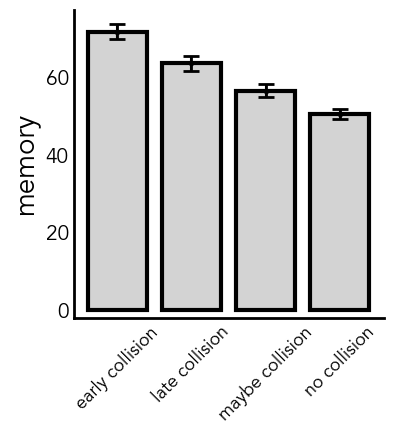

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure(figsize=(4, 4))
_data = data.groupby("cond")["acc_confidence"].describe().reset_index()
_data["ci"] = 1.96 * _data["std"] / np.sqrt(_data["count"])

# colors = ["tab:orange", "tab:blue", "tab:green", "tab:red"]
# colors = [ColorConverter().to_rgba(color, alpha=0.7) for color in colors]

plt.bar(x="cond", height="mean", yerr="ci", data=_data, ec="black", lw=3, color="lightgray")
plt.errorbar(x="cond", y="mean", yerr="ci", data=_data, fmt=".", color="black", capsize=6, lw=2, capthick=2)
plt.xticks(np.arange(4), labels=["early collision", "late collision", "maybe collision", "no collision"], rotation=45, fontsize=13)
plt.ylabel("memory")
plt.ylim(-2)
plt.show()
plt.gcf().savefig("../../figures/memory.pdf", bbox_inches="tight")

In [9]:
# accuracy as a function of how likely people think an object will be hit
col_judgments = pd.read_csv("../exp_likelihood/collision_judgments_z.csv")
col_judgments = col_judgments.rename(
    {"response": "collision_likelihood", "response_z": "z_collision_likelihood"}, axis=1
)


def merge_exp_data(df, col_judgments):
    def ci(x):
        # return 1.96 * x.std() / np.sqrt(x.size)
        return x.std() / np.sqrt(x.size)

    col_judgments = col_judgments.assign(root=col_judgments.baseImg.str.extract("(.*base)"))
    # merge blue and red bases
    col_judgments = (
        col_judgments.groupby(["root", "cond"])[["collision_likelihood", "z_collision_likelihood"]]
        .agg(
            collision_likelihood=("collision_likelihood", "mean"),
            collision_likelihood_ci=("z_collision_likelihood", ci),
            z_collision_likelihood=("collision_likelihood", "mean"),
            z_collision_likelihood_ci=("z_collision_likelihood", ci),
        )
        .reset_index()
    )
    df = df.groupby(["world", "root"])[["correct", "acc_confidence", "confidence", "confidence_z", "acc_confidence_z"]].agg(
        correct=("correct", "mean"),
        acc_confidence=("acc_confidence", "mean"),
        confidence=("confidence", "mean"),
        confidence_z=("confidence_z", "mean"),
        acc_confidence_z=("acc_confidence_z", "mean"),
        acc_confidence_z_ci=("acc_confidence_z", ci),
        confidence_z_ci=("confidence_z", ci),
        correct_ci=("correct", ci),
        acc_confidence_ci=("acc_confidence", ci),
        confidence_ci=("confidence", ci),
        N=("correct", "size"),
    ).reset_index()
    print(df.shape, col_judgments.shape)
    out = pd.merge(df, col_judgments, on="root")
    out["cond"] = pd.Categorical(out["cond"], categories=["col_early_translate", "col_late_translate", "maybecol_translate", "nocol_translate"], ordered=True)
    out["object"] = out.root.map(lookup_object)
    return out


collisions_person = merge_exp_data(data, col_judgments)

(48, 13) (48, 6)


In [7]:
pd.read_csv("../../models/output/exp1/noisysim_pars_search.csv").sort_values("r", ascending=False).head(3)

,Unnamed: 0,noise_position_moving,noise_collision_direction,noise_collision_elasticity,epsilon,rmse,r
917,917,5.0,0.8,0.6,0.10,0.064560,0.985642
907,907,4.0,0.7,0.6,0.10,0.066411,0.984828
755,755,3.0,0.8,0.5,0.15,0.067589,0.984690


In [8]:
worlds = {
    w: pgw.loadFromDict(
        json.load(open(f"../../experiments/assets/exp_likelihood/targets/{w}/{w}.json"))["world"]
    )
    for w in data.world.unique()
}
noisysim_pars = {
    "noise_position_static": 0.0,
    "noise_position_moving": 5.0,
    "noise_collision_direction": 0.8,
    "noise_collision_elasticity": 0.6,
    "noise_gravity": 0.0,
}
print(pd.DataFrame.from_dict(noisysim_pars, orient="index", columns=["value"]).assign(value=lambda x: x["value"].apply(lambda y: f"{y:.1f}")).to_latex())
# with open("../../stimuli/default_sim_noise.json") as f:
#     defaultSimNoise = json.load(f)


\begin{tabular}{ll}
\toprule
 & value \\
\midrule
noise_position_static & 0.0 \\
noise_position_moving & 5.0 \\
noise_collision_direction & 0.8 \\
noise_collision_elasticity & 0.6 \\
noise_gravity & 0.0 \\
\bottomrule
\end{tabular}



In [9]:
# bootstraps = pd.read_csv("../../models/jit_bootstrap.csv")
# bootstrap_ci = bootstraps.groupby(["world", "obj_name"]).model_p.apply(lambda group: (np.quantile(group, 0.975) - np.quantile(group, 0.025)) * 0.5)
# if "model_p_ci" in joint_predictions.columns:
#     joint_predictions = joint_predictions.drop(columns=["model_p_ci"])
# joint_predictions = joint_predictions.merge(bootstrap_ci.rename("model_p_ci"), left_on=["world", "object"], right_on=["world", "obj_name"], how="left")

In [7]:
fitting = False
if fitting:
    decays = np.linspace(0, 0.5, 11)
    losses = pd.DataFrame(columns=["rmse", "r", "decay"])
    for decay in decays:
        print(decay)
        predictions = process_model.model_predict(worlds, noisysim_pars, radius=25, n_sims=500, decay=decay)
        tmp = pd.merge(
            collisions_person[
                [
                    "world",
                    "object",
                    "correct",
                ]
            ],
            predictions.rename(columns={"obj_name": "object"}),
            on=["world", "object"],
            how="left",
        )
        losses.loc[len(losses)] = [np.sqrt(((tmp.correct - (0.667 * tmp.model_p + 0.333)) ** 2).mean()), tmp.correct.corr(tmp.model_p), decay]
    losses.to_csv("jit_fitting.csv", index=False)
else:
    losses = pd.read_csv("jit_fitting.csv")

In [12]:
losses.sort_values("r", ascending=False)

,rmse,r,decay
0,0.180849,0.865208,0.00
1,0.167965,0.864309,0.05
2,0.156700,0.863329,0.10
3,0.146264,0.861572,0.15
4,0.136746,0.858766,0.20
5,0.130720,0.853538,0.25
6,0.122667,0.853190,0.30
7,0.118673,0.842645,0.35
8,0.113569,0.840614,0.40
9,0.111255,0.834155,0.45


In [10]:
import process_model

rerun = False
if rerun:
    process_model_predictions = process_model.model_predict(
        worlds, noisysim_pars, radius=25, n_sims=1000, decay=0.0
    )
    # process_model_predictions = model_predict(worlds, noisysim_pars, radius=25, n_sims=50, decay=0.25)
    process_model_predictions.rename(columns={"obj_name": "object"}, inplace=True)
    process_model_predictions.to_csv("../../models/jit_predictions.csv", index=False)
else:
    process_model_predictions = pd.read_csv("../../models/jit_predictions.csv")
joint_predictions = pd.merge(
    collisions_person[
        [
            "collision_likelihood",
            "world",
            "object",
            "acc_confidence",
            "acc_confidence_z",
            "acc_confidence_z_ci",
            "confidence",
            "confidence_ci",
            "confidence_z",
            "confidence_z_ci",
            "correct",
            "correct_ci",
            "cond",
            "N",
        ]
    ],
    process_model_predictions,
    on=["world", "object"],
    how="left",
)

In [15]:
def simulation_predict(worlds):
    out = {}
    for wname, world in worlds.items():
        objs = set(o for o in world.objects if "bump" in o)
        for o in objs:
            out[(wname, o)] = 0.0
        print(wname)
        sims = simulate_noisypaths(world, 2/60, N=500, **noisysim_pars)

        for o in objs:
            for sim in sims:
                for col in sim["collisions"]:
                    if o in col:
                        out[(wname, o)] += 1 / len(sims)
                        break

    return pd.Series(out).reset_index().rename({"level_0": "world", "level_1": "object", 0: "model_p"}, axis=1)

rerun = False
if rerun:
    sim_predictions = simulation_predict(worlds)
    sim_predictions.to_csv("../../models/collision_predictions.csv", index=False)
    # sim_predictions.to_csv("../../models/collision_predictions.csv", index=False)
else:
    sim_predictions = pd.read_csv("../../models/collision_predictions.csv")

RMSE: 0.09449610288404382


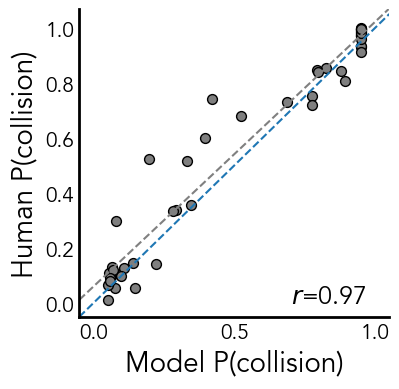

In [16]:
plt.figure(figsize=(4, 4))
joint_sims = pd.merge(
    sim_predictions,
    collisions_person[["world", "object", "collision_likelihood"]],
    on=["world", "object"],
)
joint_sims["collision_likelihood"] /= 100
# joint_sims["model_p"] = np.clip(joint_sims.model_p, 0.1, 0.9)
# joint_sims["model_p"] = joint_sims.model_p
joint_sims["model_p"] = joint_sims.model_p * (1 - 0.1) + 0.1 * 0.5
plt.scatter(
    x="model_p", y="collision_likelihood", data=joint_sims, s=50, lw=1, ec="k", color="tab:gray"
)
# plt.legend(
#     [],
#     [],
#     title=f"$r$={joint_sims.model_p.corr(joint_sims.collision_likelihood) ** 2:.2f}",
#     loc="lower right",
# )
plt.text(0.7, 0.00, f"$r$={joint_sims.model_p.corr(joint_sims.collision_likelihood):.2f}", fontsize=18, fontweight="bold")
b, a = np.polyfit(joint_sims.model_p, joint_sims.collision_likelihood, 1)
xlims = plt.xlim()

plt.xlim((0.0 - 0.05, 1.05))
plt.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
plt.axline((0, 0), (1, 1), ls="--", c="tab:blue")
plt.xlabel("Model P(collision)")
plt.ylabel("Human P(collision)")

print("RMSE:", np.sqrt(((joint_sims.model_p - joint_sims.collision_likelihood) ** 2).mean()))

plt.savefig("../../figures/plinko_collision.pdf", bbox_inches="tight")

RMSE: 0.1798695227077335


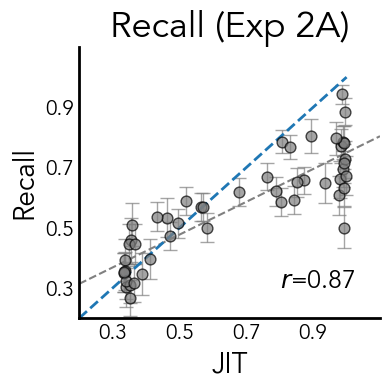

In [17]:
def logit(x, a=-1):
    # when a = -1, this is just a linear mapping
    chance = 0.333
    odds = x / (1 - x)
    return chance + (1 - chance) / (1 + (odds + 1e-5) ** a)
    # return 0.5 + 0.5 / (1 + np.exp(-odds))
    # return norm.cdf(x, loc=0, scale=1)

tmp = joint_predictions.copy()
tmp["model_logit"] = tmp.model_p * 0.667 + 0.333 # tmp.model_p.apply(logit)
# tmp["acc_confidence"] /= 100
fig, ax = plt.subplots(figsize=(4, 4))
dv = "model_logit"
plt.errorbar(
    x=dv,
    y="correct",
    yerr="correct_ci",
    # xerr="model_p_ci",
    fmt="o",
    alpha=0.7,
    lw=1,
    markeredgecolor="k",
    color="tab:gray",
    ms=np.sqrt(60),
    elinewidth=1,
    capsize=5,
    capthick=1,
    data=tmp
)

b, a = np.polyfit(tmp[dv], tmp.correct, 1)
# xlims = ax.get_xlim()
lims = (0.2, 1.1)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.axline((lims[0], a + b * lims[0]), (lims[1], a + b * lims[1]), ls="--", c="gray")
plt.plot([lims[0], 1.0], [lims[0], 1.0], ls="--", c="tab:blue", lw=2)

plt.xlabel("JIT")
plt.ylabel("Recall")
plt.title("Recall (Exp 2A)")
# plt.legend([], title=f"$r$={tmp.groupby(['world', 'cond'])[[dv, 'correct']].mean().corr().iloc[0, 1]:.2f}",
        # loc = "lower center")
plt.text(0.80, 0.3, f"$r$={tmp.groupby(['world', 'cond'])[[dv, 'correct']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
print("RMSE:", np.sqrt(((tmp["correct"] - tmp[dv]) ** 2).mean()))
plt.yticks(np.arange(0.3, 1.0, 0.2))
plt.xticks(np.arange(0.3, 1.0, 0.2))
plt.tight_layout()
fig.savefig("../../figures/plinko_model_correct.pdf", bbox_inches="tight")
plt.show()

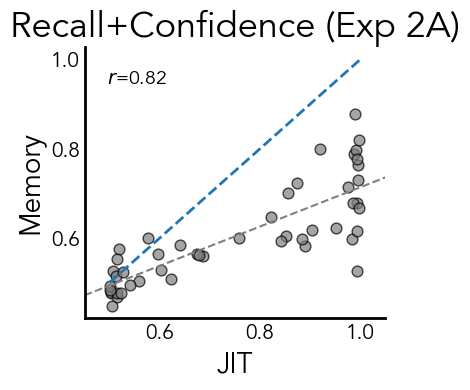

In [18]:
tmp = joint_predictions.copy()
tmp["acc_confidence"] /= 100
# tmp["model_p"] = tmp.model_p * 0.5 + 0.5
def logit(x, a=-1, b=0.5):
    odds = x / (1 - x)
    return 0.5 + b / (1 + (odds + 1e-5) ** a)
    # return 0.5 + 0.5 / (1 + np.exp(-odds))
    # return norm.cdf(x, loc=0, scale=1)
tmp["model_p"] = tmp.model_p.apply(logit, a=-1)
fig, ax = plt.subplots(figsize=(4, 4))
plt.scatter(
    x="model_p",
    y="acc_confidence",
    alpha=0.7,
    lw=1,
    ec="k",
    color="tab:gray",
    s=60,
    data=tmp
)
b, a = np.polyfit(tmp.model_p, tmp.acc_confidence, 1)
xlims = ax.get_xlim()

ax.set_xlim((0.45, 1.05))
ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
plt.plot([0.5, 1.0], [0.5, 1.0], ls="--", c="tab:blue", lw=2)

plt.xlabel("JIT")
plt.ylabel("Memory")
plt.title("Recall+Confidence (Exp 2A)")
# plt.text(0.85, 0.5, f"$r$={tmp.groupby(['world', 'cond'])[['model_p', 'acc_confidence']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.legend([], [], title=f"$r$={tmp.groupby(['world', 'cond'])[['model_p', 'acc_confidence']].mean().corr().iloc[0, 1]:.2f}", frameon=False, fontsize=18)
# loc="lower center")
plt.tight_layout()
plt.show()

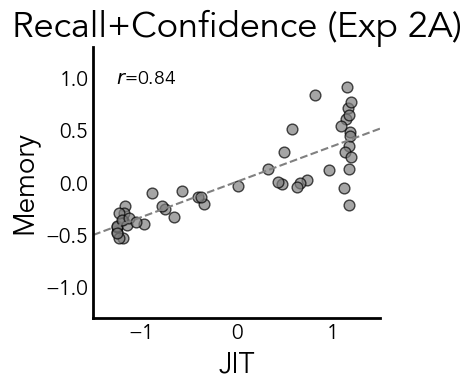

In [19]:
tmp = joint_predictions.copy()
# tmp["model_p"] = tmp.model_p * 0.5 + 0.5
def logit(x, a=-1, b=0.5):
    odds = x / (1 - x)
    return 0.5 + b / (1 + (odds + 1e-5) ** a)
    # return 0.5 + 0.5 / (1 + np.exp(-odds))
    # return norm.cdf(x, loc=0, scale=1)
tmp["model_p"] = tmp.model_p.apply(logit, a=-1)
tmp["model_p_z"] = (tmp.model_p - tmp.model_p.mean()) / tmp.model_p.std()
fig, ax = plt.subplots(figsize=(4, 4))
plt.scatter(
    x="model_p_z",
    y="acc_confidence_z",
    alpha=0.7,
    lw=1,
    ec="k",
    color="tab:gray",
    s=60,
    data=tmp
)
b, a = np.polyfit(tmp.model_p_z, tmp.acc_confidence_z, 1)

ax.set_xlim((-1.5, 1.5))
ax.set_ylim((-1.3, 1.3))
xlims = ax.get_xlim()
ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
# plt.plot([0.5, 1.0], [0.5, 1.0], ls="--", c="tab:blue", lw=2)

plt.xlabel("JIT")
plt.ylabel("Memory")
plt.title("Recall+Confidence (Exp 2A)")
# plt.text(0.85, 0.5, f"$r$={tmp.groupby(['world', 'cond'])[['model_p', 'acc_confidence']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.legend([], [], title=f"$r$={tmp.groupby(['world', 'cond'])[['model_p_z', 'acc_confidence_z']].mean().corr().iloc[0, 1]:.2f}", frameon=False, fontsize=18)
# loc="lower center")
plt.tight_layout()
plt.show()

dict_keys(['lh_ll_unlink_plinko_0091', 'lh_hl_unlink_plinko_0036', 'hh_hl_unlink_plinko_0393', 'lh_ll_unlink_plinko_0217', 'lh_hl_unlink_plinko_0110', 'lh_ll_unlink_plinko_0060', 'hh_hl_unlink_plinko_0315', 'hh_hl_unlink_plinko_0269', 'hh_hl_unlink_plinko_0240', 'lh_hl_unlink_plinko_0049', 'hh_hl_unlink_plinko_0202', 'lh_ll_unlink_plinko_0155', 'hh_hl_unlink_plinko_0246', 'hh_hl_unlink_plinko_0105', 'hh_hl_unlink_plinko_0252', 'lh_hl_unlink_plinko_0111'])


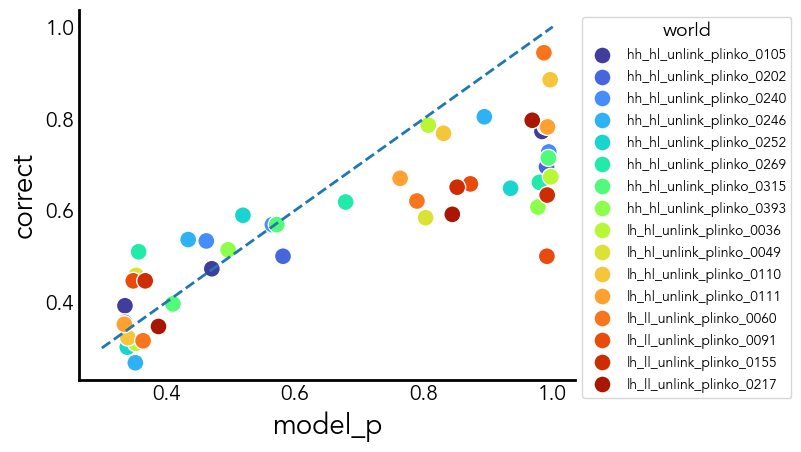

In [20]:
import seaborn as sns

tmp = joint_predictions.copy()
chance = 0.333
tmp["model_p"] = chance + (1 - chance) * tmp.model_p
p = sns.scatterplot(data=tmp, x="model_p", y="correct", hue="world", palette="turbo", s=150)
plt.plot([0.3, 1.0], [0.3, 1], ls="--", c="tab:blue", lw=2)
sns.move_legend(p, "upper left", bbox_to_anchor=(1, 1), title="world")
print(worlds.keys())

# good worlds: 0060, 0110, 0246, 0111
# indices: 5, 4, 12, 15

(-1.5, 1.5)


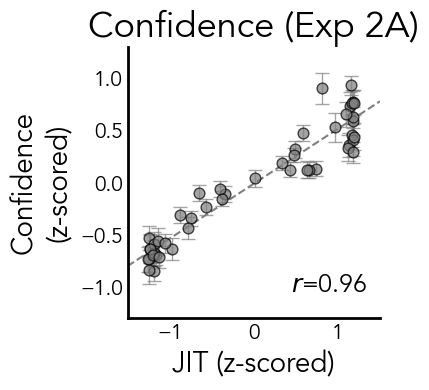

In [21]:
tmp = joint_predictions.copy()
tmp["model_p_z"] = (tmp.model_p - tmp.model_p.mean()) / tmp.model_p.std()
# tmp["confidence_ci"] /= 100
# tmp["model_p"] = tmp.model_p * 0.5 + 0.5
fig, ax = plt.subplots(figsize=(4, 4))
plt.errorbar(
    x="model_p_z",
    y="confidence_z",
#     xerr="model_p_ci",
    yerr="confidence_z_ci",
    fmt="o",
    alpha=0.7,
    lw=1,
    markeredgecolor="k",
    color="tab:gray",
    ms=np.sqrt(60),
    elinewidth=1,
    capsize=5,
    capthick=1,
    data=tmp
)
b, a = np.polyfit(tmp.model_p_z, tmp.confidence_z, 1)

ax.set_xlim((-1.5, 1.5))
ax.set_ylim((-1.3, 1.3))
xlims = ax.get_xlim()
print(xlims)
ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
plt.xlabel("JIT (z-scored)")
plt.ylabel("Confidence\n(z-scored)")
plt.title("Confidence (Exp 2A)")
plt.legend([], title=f"$r$={tmp.groupby(['world', 'cond'])[['model_p_z', 'confidence_z']].mean().corr().iloc[0, 1]:.2f}",
        loc="lower right", frameon=False, title_fontproperties={"weight": "bold", "size": 18})
# plt.text(0.75, 0.037, f"$r$={tmp.groupby(['world', 'cond'])[['model_p', 'confidence']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
        # bbox_to_anchor=(.4, .8))
plt.tight_layout()
fig.savefig("../../figures/plinko_confidence.pdf", bbox_inches="tight")
plt.show()

In [22]:
# split half correlation of collision likelihood
def split_likelihood(df):
    idx = np.random.choice(df.index, size=df.shape[0] // 2, replace=False)
    df1 = df.loc[idx, ["root", "collision_likelihood"]]
    df2 = df.loc[~df.index.isin(idx), ["root", "collision_likelihood"]]
    df1 = df1.groupby("root")["collision_likelihood"].mean().reset_index()
    df2 = df2.groupby("root")["collision_likelihood"].mean().reset_index()
    merged = pd.merge(df1, df2, on="root", suffixes=("_1", "_2"))
    return merged

_n = 50
split_cor = 0
for _ in range(_n):
    split_cor += split_likelihood(col_judgments)[["collision_likelihood_1", "collision_likelihood_2"]].corr().iloc[0, 1]
print(split_cor / _n)

0.9668279248562516


In [23]:
regression_data = pd.merge(data[["world", "object", "acc_confidence", "pid"]], process_model_predictions[["world", "object", "model_p"]], on=["world", "object"])

In [24]:
%%R -i regression_data

library(lme4)
model = lmer("acc_confidence ~ 1 + (1 | pid) + model_p", data=regression_data)
print(summary(model))
basemodel = lmer("acc_confidence ~ 1 + (1 | pid)", data=regression_data)
print("--- main effect")
print(anova(model, basemodel))

Linear mixed model fit by REML ['lmerMod']
Formula: acc_confidence ~ 1 + (1 | pid) + model_p
   Data: regression_data

REML criterion at convergence: 32986.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.1412 -0.5532  0.0935  0.7970  2.3840 

Random effects:
 Groups   Name        Variance Std.Dev.
 pid      (Intercept)  55.12    7.424  
 Residual             652.88   25.552  
Number of obs: 3520, groups:  pid, 220

Fixed effects:
            Estimate Std. Error t value
(Intercept)  49.4777     0.8946   55.31
model_p      21.2320     1.1773   18.03

Correlation of Fixed Effects:
        (Intr)
model_p -0.675
[1] "--- main effect"
Data: regression_data
Models:
basemodel: acc_confidence ~ 1 + (1 | pid)
model: acc_confidence ~ 1 + (1 | pid) + model_p
          npar   AIC   BIC logLik deviance  Chisq Df Pr(>Chisq)    
basemodel    3 33306 33325 -16650    33300                         
model        4 32998 33023 -16495    32990 310.33  1  < 2.2e-16 ***
---
Signif. codes:  0

Loading required package: Matrix
refitting model(s) with ML (instead of REML)


# Baselines

In [76]:
import baseline_models as baseline
from pyGameWorld.simulation_divergences import mae

In [77]:
from importlib import reload
reload(baseline)

<module 'baseline_models' from '/Users/tony/repos/plinko-repro/models/baseline_models.py'>

In [78]:
losses = pd.read_csv("../../models/output/exp1/vgc_fitting.csv")
losses.sort_values("r", ascending=False).head(3)

,alpha,rmse,r
96,20.096,0.283719,0.820550
97,15.097,0.295959,0.820261
95,25.095,0.271756,0.816716


In [79]:
vgc_predictions = pd.read_csv("../../models/output/exp1/vgc_predictions_alpha_20.1.csv").drop(columns=["correct"])
    # vgc_predictions = pd.read_csv("../../models/output/exp1/vgc_predictions_alpha_9.01.csv")

In [80]:
joint_predictions_all = pd.merge(
    joint_predictions,
    vgc_predictions
)

RMSE: 0.2837190162597588


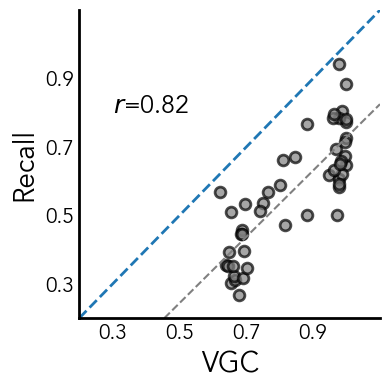

In [81]:
fig, ax = plt.subplots(figsize=(4, 4))
tmp = joint_predictions_all.copy()
# tmp["acc_confidence"] /= 100
tmp["vgc"] = tmp.vgc * 0.667 + 0.333
plt.scatter(
    x="vgc",
    y="correct",
    color="gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=tmp,
)

plt.xlabel("VGC")
plt.ylabel("Recall")

b, a = np.polyfit(tmp.vgc, tmp.correct, 1)

lims = (0.2, 1.1)
ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.axline((lims[0], a + b * lims[0]), (lims[1], a + b * lims[1]), ls="--", c="gray")
ax.axline((lims[0], lims[0]), (lims[1], lims[1]), ls="--", c="tab:blue", lw=2)
plt.text(0.3, 0.8, f"$r$={tmp.groupby(['world', 'object'])[['vgc', 'correct']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.xticks(np.arange(0.3, 1.1, 0.2))
plt.yticks(np.arange(0.3, 1.1, 0.2))
plt.tight_layout()
print("RMSE:", np.sqrt(((tmp["correct"] - tmp["vgc"]) ** 2).mean()))
fig.savefig("../../figures/plinko_vgc_baseline.pdf")
plt.show()

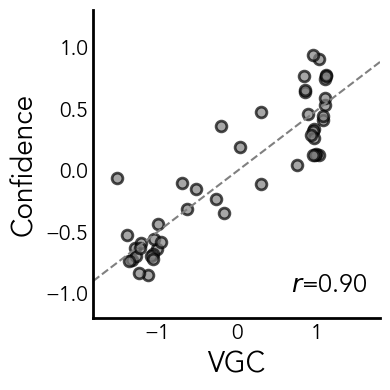

In [82]:
fig, ax = plt.subplots(figsize=(4, 4))
tmp = joint_predictions_all.copy()
# tmp["acc_confidence"] /= 100
# tmp["confidence"] /= 100
# tmp["vgc"] = tmp.vgc * 0.5 + 0.5
tmp["vgc_z"] = (tmp.vgc - tmp.vgc.mean()) / tmp.vgc.std()
plt.scatter(
    x="vgc_z",
    y="confidence_z",
    color="gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=tmp,
)

plt.xlabel("VGC")
plt.ylabel("Confidence")

b, a = np.polyfit(tmp.vgc_z, tmp.confidence_z, 1)

xlims = (-1.8, 1.8)
ax.set_xlim(xlims)
ax.set_ylim((-1.2, 1.3))
ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
# plt.text(0.3, 0.4, f"$r$={tmp.groupby(['world', 'object'])[['vgc', 'confidence']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.legend([], [], title=f"$r$={tmp.groupby(['world', 'object'])[['vgc_z', 'confidence_z']].mean().corr().iloc[0, 1]:.2f}", loc="lower right", frameon=False, title_fontproperties={"weight": "bold", "size": 18})
# plt.xticks(np.arange(0.3, 1.1, 0.2))
# plt.yticks(np.arange(0.3, 1.1, 0.2))
plt.tight_layout()
fig.savefig("../../figures/plinko_vgc_baseline_confidence.pdf")
plt.show()

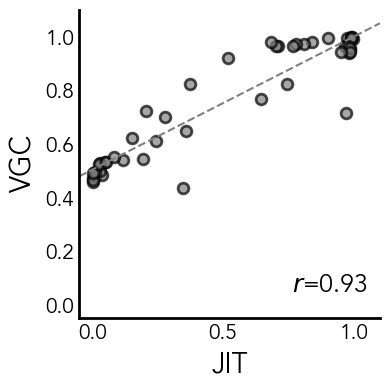

In [83]:
fig, ax = plt.subplots(figsize=(4, 4))
tmp = joint_predictions_all.copy()
plt.scatter(
    x="model_p",
    y="vgc",
    color="gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=tmp,
)

plt.xlabel("JIT")
plt.ylabel("VGC")

b, a = np.polyfit(tmp.model_p, tmp.vgc, 1)

xlims = (-0.05, 1.1)
ax.set_xlim(xlims)
ax.set_ylim((-0.05, 1.1))
ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
plt.legend([], [], title=f"$r$={tmp.groupby(['world', 'object'])[['vgc', 'model_p']].mean().corr().iloc[0, 1]:.2f}", title_fontproperties = {"size":18, "weight":"bold"}, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

In [84]:
losses = pd.read_csv("../../models/output/exp1/vgc_fitting.csv")
losses.sort_values("rmse", ascending=True).head(3)

,alpha,rmse,r
0,370.026,0.191874,0.636713
1,365.027,0.191874,0.637047
2,375.025,0.191874,0.636388


RMSE: 0.19187415868355984


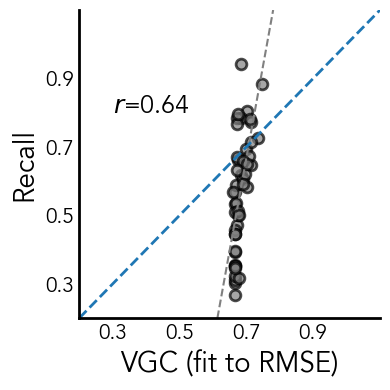

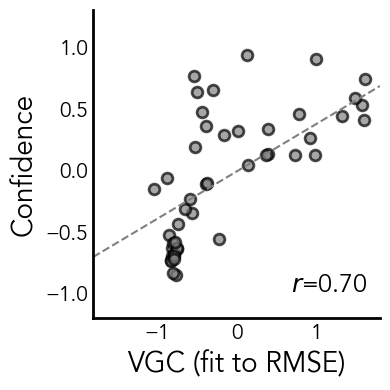

In [85]:
rmse_vgc_predictions = pd.read_csv("../../models/output/exp1/vgc_predictions_alpha_370.03.csv").drop(columns=["correct"])
tmp = pd.merge(
    joint_predictions,
    rmse_vgc_predictions
)

fig, ax = plt.subplots(figsize=(4, 4))
# tmp["acc_confidence"] /= 100
tmp["vgc"] = tmp.vgc * 0.667 + 0.333
plt.scatter(
    x="vgc",
    y="correct",
    color="gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=tmp,
)

plt.xlabel("VGC (fit to RMSE)")
plt.ylabel("Recall")

b, a = np.polyfit(tmp.vgc, tmp.correct, 1)

lims = (0.2, 1.1)
ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.axline((lims[0], a + b * lims[0]), (lims[1], a + b * lims[1]), ls="--", c="gray")
ax.axline((lims[0], lims[0]), (lims[1], lims[1]), ls="--", c="tab:blue", lw=2)
plt.text(0.3, 0.8, f"$r$={tmp.groupby(['world', 'object'])[['vgc', 'correct']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.xticks(np.arange(0.3, 1.1, 0.2))
plt.yticks(np.arange(0.3, 1.1, 0.2))
plt.tight_layout()
print("RMSE:", np.sqrt(((tmp["correct"] - tmp["vgc"]) ** 2).mean()))
fig.savefig("../../figures/plinko_vgc_baseline_rmse.pdf")

fig, ax = plt.subplots(figsize=(4, 4))
tmp["vgc_z"] = (tmp.vgc - tmp.vgc.mean()) / tmp.vgc.std()
plt.scatter(
    x="vgc_z",
    y="confidence_z",
    color="gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=tmp,
)

plt.xlabel("VGC (fit to RMSE)")
plt.ylabel("Confidence")

b, a = np.polyfit(tmp.vgc_z, tmp.confidence_z, 1)

xlims = (-1.8, 1.8)
ax.set_xlim(xlims)
ax.set_ylim((-1.2, 1.3))
ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
# plt.text(0.3, 0.4, f"$r$={tmp.groupby(['world', 'object'])[['vgc', 'confidence']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.legend([], [], title=f"$r$={tmp.groupby(['world', 'object'])[['vgc_z', 'confidence_z']].mean().corr().iloc[0, 1]:.2f}", loc="lower right", frameon=False, title_fontproperties={"weight": "bold", "size": 18})
# plt.xticks(np.arange(0.3, 1.1, 0.2))
# plt.yticks(np.arange(0.3, 1.1, 0.2))
plt.tight_layout()
fig.savefig("../../figures/plinko_vgc_baseline_confidence_rmse.pdf")
plt.show()

In [86]:
regression_data = pd.merge(data[["world", "object", "acc_confidence", "correct", "pid"]], joint_predictions_all[["world", "object", "model_p", "vgc"]], on=["world", "object"])
regression_data["correct"] = regression_data["correct"].astype(int)

In [87]:
%%R -i regression_data

library(lme4)
model = glmer("correct ~ 1 + (1 | pid) + model_p + vgc", data=regression_data, family=binomial)
print(summary(model))
basemodel = glmer("correct ~ 1 + (1 | pid) + model_p", data=regression_data, family=binomial)
print("--- main effect")
print(anova(model, basemodel))

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ 1 + (1 | pid) + model_p + vgc
   Data: regression_data

     AIC      BIC   logLik deviance df.resid 
  4483.7   4508.4  -2237.9   4475.7     3516 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5298 -0.9072  0.5163  0.7605  1.8023 

Random effects:
 Groups Name        Variance Std.Dev.
 pid    (Intercept) 0.3074   0.5545  
Number of obs: 3520, groups:  pid, 220

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -0.3727     0.2279  -1.635    0.102    
model_p       1.7007     0.2411   7.054 1.74e-12 ***
vgc          -0.1721     0.4256  -0.404    0.686    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
        (Intr) modl_p
model_p  0.766       
vgc     -0.949 -0.904
[1] "--- main effect"
Data: regression_data
Models:
basemodel: correct ~ 1 + (1 | pi

In [88]:
joint_predictions_all

,collision_likelihood,world,object,acc_confidence,acc_confidence_z,acc_confidence_z_ci,confidence,confidence_ci,confidence_z,confidence_z_ci,correct,correct_ci,cond,N,model_p,vgc,alpha
0,91.083333,hh_hl_unlink_plinko_0105,topbump_1,78.912281,0.610825,0.139467,35.929825,2.276592,0.739124,0.133100,0.771930,0.056070,col_early_translate,57,0.974836,0.996246,20.096
1,33.346154,hh_hl_unlink_plinko_0105,bottombump_0,52.863636,-0.253781,0.075967,17.263636,1.509971,-0.344425,0.070557,0.472727,0.047820,maybecol_translate,110,0.206490,0.724171,20.096
2,6.583333,hh_hl_unlink_plinko_0105,topbump_4,47.921569,-0.472255,0.105011,15.450980,2.263836,-0.731529,0.122399,0.392157,0.069046,nocol_translate,51,0.004301,0.472474,20.096
3,99.461538,hh_hl_unlink_plinko_0202,topbump_0,67.779661,0.351952,0.131254,31.406780,2.195995,0.455839,0.110278,0.694915,0.060459,col_early_translate,59,0.985444,0.952342,20.096
4,35.666667,hh_hl_unlink_plinko_0202,bottombump_2,55.933962,-0.207774,0.091725,23.311321,1.647801,-0.109536,0.079333,0.500000,0.048795,maybecol_translate,106,0.372175,0.824253,20.096
5,10.846154,hh_hl_unlink_plinko_0202,topbump_2,47.728814,-0.426422,0.096474,12.203390,1.841114,-0.528468,0.116622,0.355932,0.062869,nocol_translate,59,0.004017,0.459516,20.096
6,93.500000,hh_hl_unlink_plinko_0240,topbump_1,76.327273,0.483420,0.134294,34.981818,2.307431,0.769570,0.112514,0.727273,0.060606,col_early_translate,55,0.990746,0.999601,20.096
7,74.076923,hh_hl_unlink_plinko_0240,bottombump_1,56.293578,-0.142759,0.091433,22.403670,1.607995,-0.061915,0.077042,0.568807,0.047655,maybecol_translate,109,0.347465,0.433870,20.096
8,14.083333,hh_hl_unlink_plinko_0240,topbump_0,56.400000,-0.227483,0.104698,17.000000,1.865839,-0.437365,0.108548,0.533333,0.064950,nocol_translate,60,0.193711,0.545337,20.096
9,98.083333,hh_hl_unlink_plinko_0246,topbump_3,79.941176,0.837168,0.142291,37.549020,2.227865,0.905979,0.147478,0.803922,0.056148,col_early_translate,51,0.840826,0.980431,20.096


In [89]:
log_likelihoods = []
for (world, obj), group in joint_predictions_all.groupby(["world", "object"]):
    human_p = group.correct.iloc[0]
    jit_p = group.model_p.iloc[0] * 0.667 + 0.333
    vgc_p = group.vgc.iloc[0] * 0.667 + 0.333
    random_p = 0.333
    ceiling_p = human_p
    N = group.N.iloc[0]
    jit_ll = N * (human_p * np.log(jit_p + 1e-3) + (1 - human_p) * np.log(1 - jit_p + 1e-3))
    vgc_ll = N * (human_p * np.log(vgc_p + 1e-3) + (1 - human_p) * np.log(1 - vgc_p + 1e-3))
    random_ll = N * (human_p * np.log(random_p + 1e-3) + (1 - human_p) * np.log(1 - random_p + 1e-3))
    ceiling_ll = N * (human_p * np.log(ceiling_p + 1e-3) + (1 - human_p) * np.log(1 - ceiling_p + 1e-3))
    log_likelihoods.append((world, obj, N, jit_p, vgc_p, human_p, jit_ll, vgc_ll, random_ll, ceiling_ll))
log_likelihoods = pd.DataFrame(log_likelihoods, columns=["world", "object", "N", "jit_p", "vgc_p", "human_p", "jit_ll", "vgc_ll", "random_ll", "ceiling_ll"])

In [90]:
print(log_likelihoods[["jit_ll", "vgc_ll", "random_ll", "ceiling_ll"]].sum())
log_likelihoods

jit_ll       -2849.622435
vgc_ll       -3621.536517
random_ll    -2834.224460
ceiling_ll   -2211.158605
dtype: float64


,world,object,N,jit_p,vgc_p,human_p,jit_ll,vgc_ll,random_ll,ceiling_ll
0,hh_hl_unlink_plinko_0105,bottombump_0,110,0.470729,0.816022,0.472727,-75.863523,-108.384698,-80.425035,-75.862693
1,hh_hl_unlink_plinko_0105,topbump_1,57,0.983216,0.997496,0.771930,-53.082626,-73.566145,-53.496101,-30.491398
2,hh_hl_unlink_plinko_0105,topbump_4,51,0.335869,0.648140,0.392157,-34.402138,-40.934360,-34.439766,-34.052965
3,hh_hl_unlink_plinko_0202,bottombump_2,106,0.581241,0.882777,0.500000,-74.674093,-119.712881,-79.504314,-73.261813
4,hh_hl_unlink_plinko_0202,topbump_0,59,0.990291,0.968212,0.694915,-82.019132,-62.800819,-52.223594,-36.173702
5,hh_hl_unlink_plinko_0202,topbump_2,59,0.335679,0.639497,0.355932,-38.345585,-48.020158,-38.360650,-38.293592
6,hh_hl_unlink_plinko_0240,bottombump_1,109,0.564759,0.622391,0.568807,-74.303740,-74.948863,-86.953040,-74.299872
7,hh_hl_unlink_plinko_0240,topbump_0,60,0.462205,0.696740,0.533333,-41.942502,-44.833495,-46.388736,-41.335519
8,hh_hl_unlink_plinko_0240,topbump_1,55,0.993828,0.999734,0.727273,-74.270138,-100.050408,-49.916578,-32.117532
9,hh_hl_unlink_plinko_0246,bottombump_1,110,0.434067,0.748716,0.536364,-78.046280,-87.232726,-85.277065,-75.735245


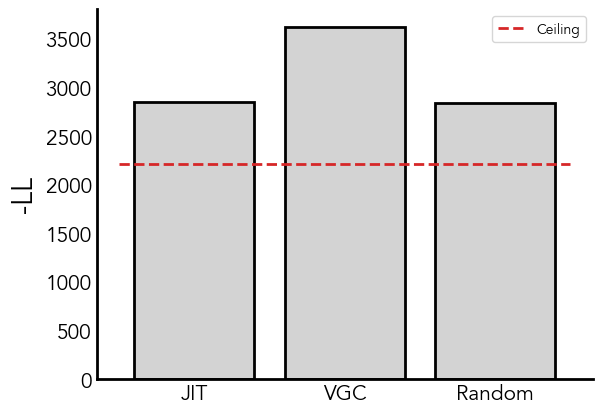

In [91]:
plt.bar(
    x=["JIT", "VGC", "Random"],
    height=-log_likelihoods[["jit_ll", "vgc_ll", "random_ll"]].sum().values,
    color="lightgray",
    ec="k",
    lw=2,
)
plt.ylabel("-LL")
plt.plot([ -0.5, 2.5], [-log_likelihoods["ceiling_ll"].sum(), -log_likelihoods["ceiling_ll"].sum()], ls="--", color="tab:red", lw=2, label="Ceiling")
plt.legend()
plt.savefig("../../figures/plinko_log_likelihoods.pdf", bbox_inches="tight", dpi=300)

In [92]:
reload(baseline)

<module 'baseline_models' from '/Users/tony/repos/plinko-repro/models/baseline_models.py'>

In [93]:
rerun = False
if rerun:
    relevance_scores_translate = baseline.counterfactual_translate(worlds, noisysim_pars)
    relevance_translate_df = pd.DataFrame(baseline.batch_results(relevance_scores_translate, divergence=mae))
    relevance_translate_df = relevance_translate_df.rename(columns = {"value": "relevance_translate"})
    relevance_translate_df["object"] = relevance_translate_df["obj_name"].str.replace("#1", "")

    relevance_scores_del = baseline.counterfactual_delete(worlds, noisysim_pars)
    relevance_del_df = pd.DataFrame(baseline.batch_results(relevance_scores_del, divergence=mae))
    relevance_del_df = relevance_del_df.rename(columns = {"value": "relevance_del", "obj_name": "object"})
    relevance_translate_df.to_csv("../../models/relevance_translate.csv", index=False)
    relevance_del_df.to_csv("../../models/relevance_del.csv", index=False)
else:
    relevance_translate_df = pd.read_csv("../../models/relevance_translate.csv")
    relevance_del_df = pd.read_csv("../../models/relevance_del.csv")

In [94]:
def normalize_relevance(group, colname, alpha=1):
    @lru_cache
    def get_simulations(wname):
        jdict = json.load(open(f"../../experiments/assets/exp_likelihood/targets/{wname}/{wname}.json"))
        return jdict["outcome"]["noisePaths"]

    reference_sims = get_simulations(group.world)
    endpositions = np.array([p["path"]["FOCUS"][-1][0] for p in reference_sims])
    # print(endpositions)
    # print(len(reference_sims))
    uniform_sims = np.linspace(0, 600, len(reference_sims))

    normalizer = mae(endpositions, uniform_sims)
    # normalize relative to how much better your predictions are compared to uniform
    norm = group[colname] / normalizer
    return np.exp(alpha * norm) / (1 + np.exp(alpha * norm))

In [95]:
fitting = False
if fitting:
    # best alpha: 4.06
    for alpha in np.linspace(0.1, 10, 21):
        tmp = relevance_translate_df.copy()
        tmp["relevance_norm"] = tmp.apply(normalize_relevance, colname="relevance_translate", alpha=alpha, axis=1)
        joint_tmp = pd.merge(
            joint_predictions,
            tmp[["world", "object", "relevance_norm"]],
            on=["world", "object"],
        )
        r = joint_tmp.groupby(["world", "cond"])[["correct", "relevance_norm"]].mean().corr().iloc[0, 1]
        print(f"alpha: {alpha}, r: {r}")

In [96]:
relevance_translate_df["relevance_norm"] = relevance_translate_df.apply(normalize_relevance, colname="relevance_translate", alpha=4.06, axis=1)
relevance_del_df["relevance_del_norm"] = relevance_del_df.apply(normalize_relevance, colname="relevance_del", alpha=4.06, axis=1)

In [97]:
def tmp(relevance, data):
    data_group = data.groupby(["world", "object"])[["correct", "confidence_z"]].mean().reset_index()
    return (
        pd.merge(data_group, relevance, on=["world", "object"])
        # .query("correct.notnull()")
        .reset_index(drop=True)
    )


counterfactuals_del = tmp(relevance_del_df, collisions_person)
counterfactuals_translate = tmp(
    relevance_translate_df.groupby(["world", "object"])[["relevance_translate", "relevance_norm"]].mean().reset_index(),
    collisions_person,
)

RMSE: 0.27


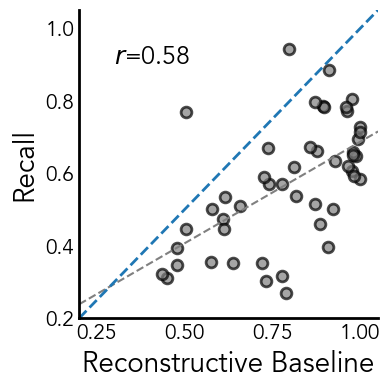

In [98]:
fig, ax = plt.subplots(figsize=(4, 4))
tmp = counterfactuals_translate.copy()
tmp["relevance_norm"] = (2 * tmp.relevance_norm - 1) * 0.667 + 0.333
plt.scatter(
    x="relevance_norm",
    y="correct",
    color="tab:gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=tmp,
)

ticks, labels = plt.yticks()
# plt.yticks(ticks, [int(o.get_text()) / 100 for o in labels])
lims = (0.2, 1.05)
ax.set_xlim(lims)
ax.set_ylim(lims)
b, a = np.polyfit(tmp.relevance_norm, tmp.correct, 1)
# xlims = ax.get_xlim()

ax.axline((lims[0], a + b * lims[0]), (lims[1], a + b * lims[1]), ls="--", c="gray")
ax.axline((lims[0], lims[0]), (lims[1], lims[1]), ls="--", c="tab:blue", lw=2)

plt.xlabel("Reconstructive Baseline")
plt.ylabel("Recall")
# plt.legend(
#     [],
#     title=f"$r$={tmp[['relevance_norm', 'correct']].corr().iloc[0, 1]:.2f}",
#     loc="lower right"
# )
plt.text(0.3, 0.9, f"$r$={tmp[['relevance_norm', 'correct']].corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.tight_layout()
print(f"RMSE: {np.sqrt(((tmp.relevance_norm - tmp.correct) ** 2).mean()):.2f}")
fig.savefig("../../figures/counterfactual_baseline_translate.pdf")
plt.show()

RMSE: 0.78


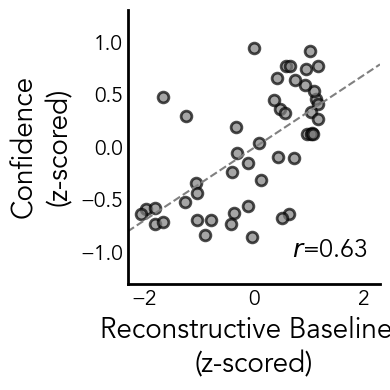

In [99]:
fig, ax = plt.subplots(figsize=(4, 4))
tmp = counterfactuals_translate.copy()
# tmp["confidence"] /= 100
tmp["relevance_norm_z"] = (
    tmp.relevance_norm - tmp.relevance_norm.mean()
) / tmp.relevance_norm.std()
plt.scatter(
    x="relevance_norm_z",
    y="confidence_z",
    color="tab:gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=tmp,
)

ticks, labels = plt.yticks()
# plt.yticks(ticks, [int(o.get_text()) / 100 for o in labels])
xlims = (-2.3, 2.3)
ylims = (-1.3, 1.3)
ax.set_xlim(xlims)
ax.set_ylim(ylims)
b, a = np.polyfit(tmp.relevance_norm_z, tmp.confidence_z, 1)
# xlims = ax.get_xlim()

ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")

plt.xlabel("Reconstructive Baseline  \n(z-scored)")
plt.ylabel("Confidence\n(z-scored)")
# plt.text(0.1, 0.4, f"$r$={tmp[['relevance_norm_z', 'confidence_z']].corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
plt.legend(
    [],
    [],
    title=f"$r$={tmp[['relevance_norm_z', 'confidence_z']].corr().iloc[0, 1]:.2f}",
    loc="lower right",
    frameon=False,
    title_fontproperties={"weight": "bold", "size": 18},
)
plt.tight_layout()
print(f"RMSE: {np.sqrt(((tmp.relevance_norm_z - tmp.confidence_z) ** 2).mean()):.2f}")
fig.savefig("../../figures/counterfactual_baseline_translate_confidence.pdf", bbox_inches="tight")
plt.show()

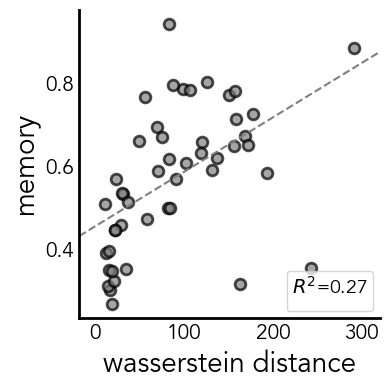

In [100]:
fig, ax = plt.subplots(figsize=(4, 4))
plt.scatter(
    x="relevance_del",
    y="correct",
    color="tab:gray",
    alpha=0.7,
    lw=2,
    ec="k",
    s=60,
    data=counterfactuals_del,
)

ticks, labels = plt.yticks()
# plt.yticks(ticks, [int(o.get_text()) / 100 for o in labels])
b, a = np.polyfit(counterfactuals_del.relevance_del, counterfactuals_del.correct, 1)
xlims = ax.get_xlim()

ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")

plt.xlabel("wasserstein distance")
plt.ylabel("memory")
plt.legend(
    [],
    title=f"$R^2$={counterfactuals_del[['relevance_del', 'correct']].corr().iloc[0, 1] ** 2:.2f}",
    loc="lower right"
)
plt.tight_layout()
fig.savefig("../../figures/counterfactual_baseline_del.pdf")
plt.show()

In [101]:
joint_predictions_all = pd.merge(
    joint_predictions,
    counterfactuals_del[["world", "object", "relevance_del_norm"]],
    on=["world", "object"],
    how="left",
)
joint_predictions_all = pd.merge(
    joint_predictions_all,
    counterfactuals_translate[["world", "object", "relevance_norm"]],
    on=["world", "object"],
    how="left",
)
joint_predictions_all = pd.merge(
    joint_predictions_all,
    vgc_predictions,
    on=["world", "object"],
    how="left"
)

In [102]:
models_to_cols = {
    "jit": joint_predictions_all.model_p,
    "translate": joint_predictions_all.relevance_norm,
    "del": joint_predictions_all.relevance_del_norm,
    "vgc": joint_predictions_all.vgc
}

pcorrs = {}
for col1 in ["jit", "del", "translate", "vgc"]:
    for col2 in ["jit", "del", "translate", "vgc"]:
        if col1 == col2:
            continue
        pcorrs[f"{col1}_semipartial{col2}"] = semipartial_correlation(models_to_cols[col1], joint_predictions_all.correct, models_to_cols[col2])
        pcorrs[f"{col1}_partial{col2}"] = partial_correlation(models_to_cols[col1], joint_predictions_all.correct, models_to_cols[col2])

pcorrs

{'jit_semipartialdel': 0.604635525042084,
 'jit_partialdel': 0.7701045755037406,
 'jit_semipartialtranslate': 0.6443327500240353,
 'jit_partialtranslate': 0.7895184376278395,
 'jit_semipartialvgc': 0.2779761328486248,
 'jit_partialvgc': 0.4863341868852678,
 'del_semipartialjit': 0.010253648223195973,
 'del_partialjit': 0.020468161687536665,
 'del_semipartialtranslate': 0.27345157610704296,
 'del_partialtranslate': 0.33506765118930987,
 'del_semipartialvgc': -0.01072136827677219,
 'del_partialvgc': -0.018757610121949493,
 'translate_semipartialjit': 0.009403551100160926,
 'translate_partialjit': 0.01877121197894134,
 'translate_semipartialdel': 0.15867728046640628,
 'translate_partialdel': 0.20210208407315197,
 'translate_semipartialvgc': 0.0032674141817310284,
 'translate_partialvgc': 0.005716516749137017,
 'vgc_semipartialjit': 0.03912071709812646,
 'vgc_partialjit': 0.0780921234537385,
 'vgc_semipartialdel': 0.5383805611754131,
 'vgc_partialdel': 0.685717785924999,
 'vgc_semipartialt

# Heatmaps

In [42]:
tmp = pd.merge(joint_predictions, vgc_predictions, on=["world", "object"])
tmp = pd.merge(
    tmp,
    tmp.groupby("world")
    .apply(lambda g: np.sqrt((((0.667 * g.model_p + 0.333) - g.correct) ** 2).mean()))
    .reset_index()
    .rename(columns={0: "jit_rmse"}),
    on="world",
)
tmp = pd.merge(
    tmp,
    tmp.groupby("world")
    .apply(lambda g: np.sqrt((((0.667 * g.vgc + 0.333) - g.correct) ** 2).mean()))
    .reset_index()
    .rename(columns={0: "vgc_rmse"}),
    on="world",
)
tmp["jit_vgc_diff"] = tmp.vgc_rmse - tmp.jit_rmse
tmp["world_idx"] = tmp.world.apply(lambda x: list(worlds.keys()).index(x))
tmp[["world_idx", "world", "jit_vgc_diff"]].sort_values("jit_vgc_diff", ascending=False).drop_duplicates("world")

,world_idx,world,jit_vgc_diff
38,5,lh_ll_unlink_plinko_0060,0.198539
10,12,hh_hl_unlink_plinko_0246,0.194226
1,13,hh_hl_unlink_plinko_0105,0.153374
32,4,lh_hl_unlink_plinko_0110,0.143239
5,10,hh_hl_unlink_plinko_0202,0.140090
12,14,hh_hl_unlink_plinko_0252,0.139659
45,3,lh_ll_unlink_plinko_0217,0.139018
24,1,lh_hl_unlink_plinko_0036,0.108974
35,15,lh_hl_unlink_plinko_0111,0.107054
19,6,hh_hl_unlink_plinko_0315,0.100705


In [43]:
import cmocean
import matplotlib.cm
import matplotlib.colors

def heatmap(world, model_preds, human_preds, axes=None, cmap=cmocean.cm.algae, ground_truth=True, norm=None):
    tmp = model_preds.set_index("object")

    humans = human_preds.set_index("object")
    # humans["correct"] = (humans.correct - humans.correct.min()) / (humans.correct.max() - humans.correct.min())
    # humans["acc_confidence"] = (humans.acc_confidence - humans.acc_confidence.min()) / (humans.acc_confidence.max() - humans.acc_confidence.min())
    # humans["acc_confidence"] = humans.acc_confidence / 100
    # cmap = matplotlib.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=0, vmax=1))
    if not norm:
        norm = matplotlib.colors.Normalize(vmin=0, vmax=1)

    colors = {}
    widths = {}
    hatch = {}
    for n in world.objects:
        if "bump" not in n:
            continue
        if n not in humans.index:
            colors[n] = (240, 240, 240)
            widths[n] = 1
            hatch[n] = {"hatch": "////", "ec": "gray"}
            continue
        colors[n] = [255 * v for v in cmap(norm(humans.loc[n]["correct"]))]
        widths[n] = 1
        hatch[n] = {"hatch": "", "ec": "k"}

    idx = 0
    nplots = 4 if ground_truth else 3
    if axes is None:
        plt.subplot(1, nplots, idx + 1)
    else:
        plt.sca(axes[0])

    if ground_truth:
        viewer._draw_world_mpl(world)
        # viewer._draw_world_mpl(worlds[wname], obj_colors={n: (255 * v for v in cmap(human_preds.loc[n]["acc_confidence"])) for n in human_preds.index})
        # plt.axis("off")
        # plt.axis('equal')
        # plt.gca().autoscale_view()
        plt.title("Ground Truth", fontsize=15)
        idx += 1

    if axes is None:
        plt.subplot(1, nplots, idx + 1)
    else:
        plt.sca(axes[idx])
    idx += 1

    viewer._draw_world_mpl(world, obj_colors=colors, obj_widths=widths, other_object_props=hatch)
    # viewer._draw_world_mpl(worlds[wname], obj_colors={n: (255 * v for v in cmap(human_preds.loc[n]["acc_confidence"])) for n in human_preds.index})
    # plt.axis("off")
    # plt.axis('equal')
    # plt.gca().autoscale_view()
    plt.title("Humans", fontsize=15)

    if axes is None:
        plt.subplot(1, nplots, idx + 1)
    else:
        plt.sca(axes[idx])
    idx += 1

    jit_colors = colors.copy()
    for n in jit_colors:
        if n not in humans.index:
            continue
        # jit_colors[n] = [255 * v for v in cmap(norm(tmp.loc[n]["model_p"] / 2 + 0.5))]
        # jit_colors[n] = [255 * v for v in cmap(norm(chance + (1 - chance) * tmp.loc[n]["model_p"]))]
        jit_colors[n] = [255 * v for v in cmap(norm(tmp.loc[n]["model_p"] * 0.667 + 0.333))]
    viewer._draw_world_mpl(world, obj_colors=jit_colors, obj_widths=widths, other_object_props=hatch)
    # plt.axis("off")
    # plt.axis('equal')
    # plt.gca().autoscale_view()
    plt.title("JIT", fontsize=15)

    if axes is None:
        plt.subplot(1, nplots, idx + 1)
    else:
        plt.sca(axes[idx])

    vgc_colors = colors.copy()
    for n in vgc_colors:
        if n not in humans.index:
            continue
        # vgc_colors[n] = [255 * v for v in cmap(norm(tmp.loc[n]["vgc"] / 2 + 0.5))]
        # vgc_colors[n] = [255 * v for v in cmap(norm(chance + (1 - chance) * tmp.loc[n]["vgc"]))]
        vgc_colors[n] = [255 * v for v in cmap(norm(tmp.loc[n]["vgc"] * 0.667 + 0.333))]
    viewer._draw_world_mpl(world, obj_colors=vgc_colors, obj_widths=widths, other_object_props=hatch)
    # plt.axis("off")
    # plt.axis('equal')
    plt.title("VGC", fontsize=15)

    if axes is not None:
        for ax in axes:
            ax.autoscale_view()
            ax.set_aspect('equal', 'box')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines[:].set_visible(False)
    plt.tight_layout()

0.26785714285714285


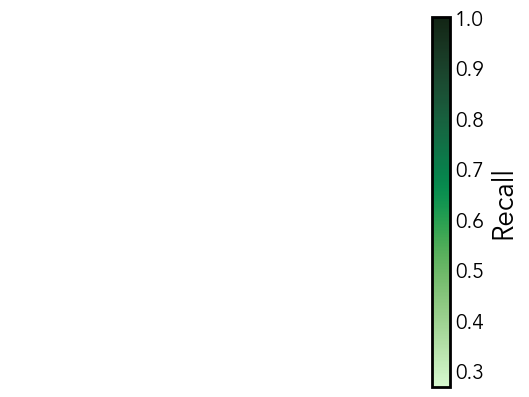

In [44]:
import matplotlib.cm as cm
plt.plot([0, 0], [0, 0])
norm = matplotlib.colors.Normalize(vmin=joint_predictions_all.correct.min(), vmax=1)
print(joint_predictions_all.correct.min())
plt.axis("equal")
plt.axis("off")
plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), ax=plt.gca(), label="Recall")
# plt.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=1), cmap=cmocean.cm.algae), ax=plt.gca(), label="Memory", orientation="horizontal")
plt.savefig("../../figures/colorbar.pdf", bbox_inches="tight", dpi=300)

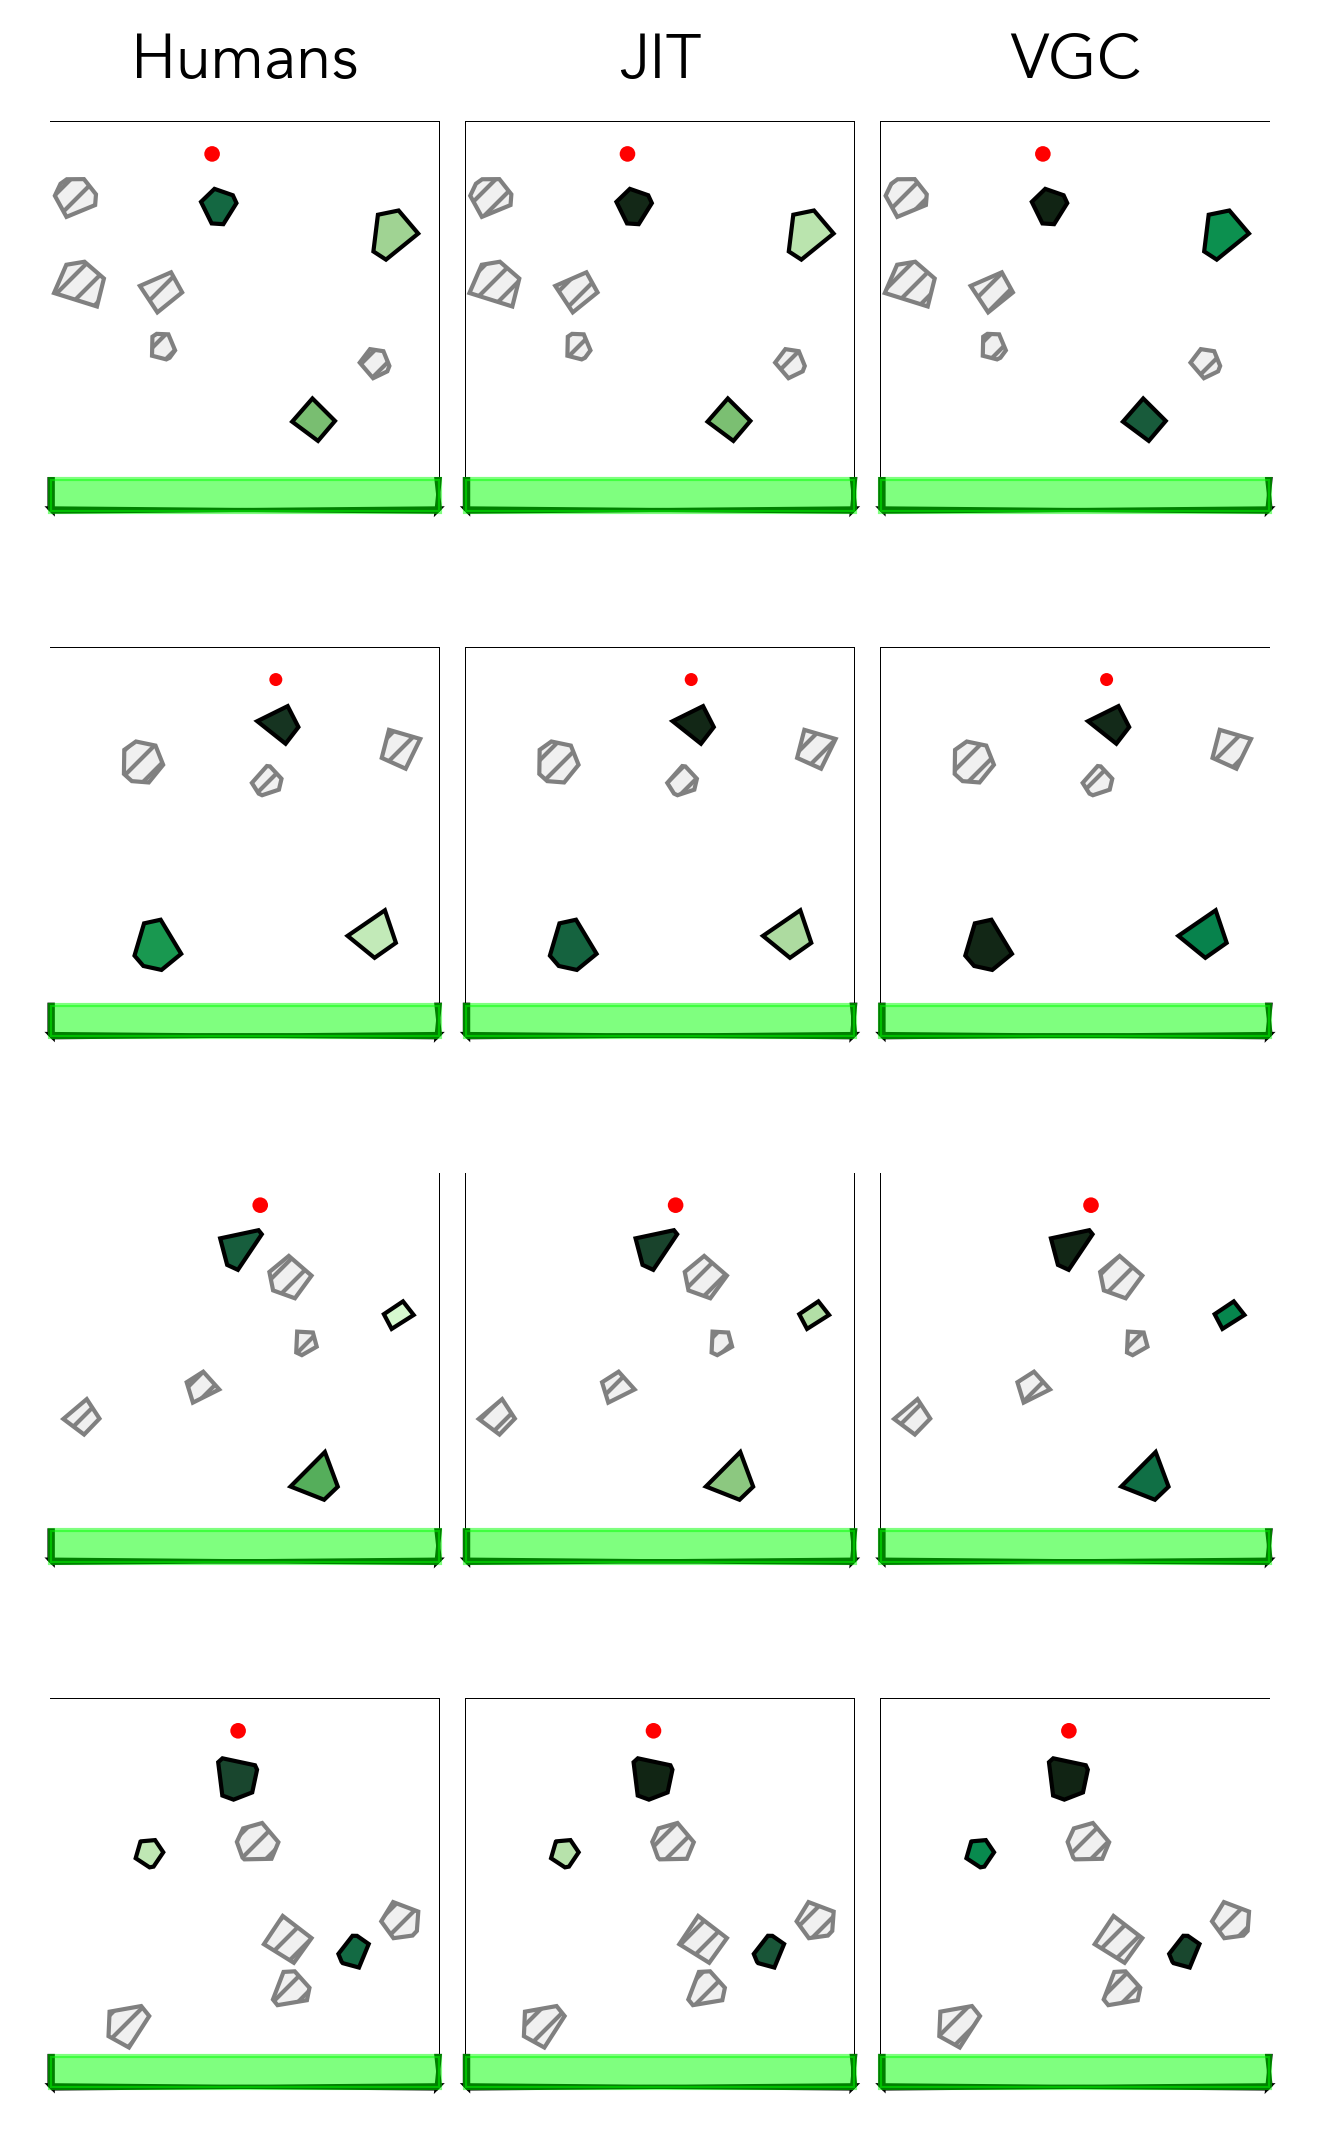

In [45]:
world_idxs = [13, 5, 12, 4]

rows = len(world_idxs)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(1.5 * cols, 2.1 * rows - 1), dpi=300)
for i, idx in enumerate(world_idxs):
    wname = list(worlds)[idx]
    world = worlds[wname]
    norm = matplotlib.colors.Normalize(vmin=joint_predictions_all.correct.min(), vmax=1)
    heatmap(world, joint_predictions_all[joint_predictions_all.world == wname], collisions_person[collisions_person.world == wname], axes=axes[i], ground_truth=False, norm=norm)
    tmp = joint_predictions_all[joint_predictions_all.world == wname]
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")
fig.subplots_adjust(hspace=0.5, wspace=0.1, top=0.85)
plt.tight_layout()
plt.savefig("../../figures/physics_heatmaps_selected.pdf")

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that 

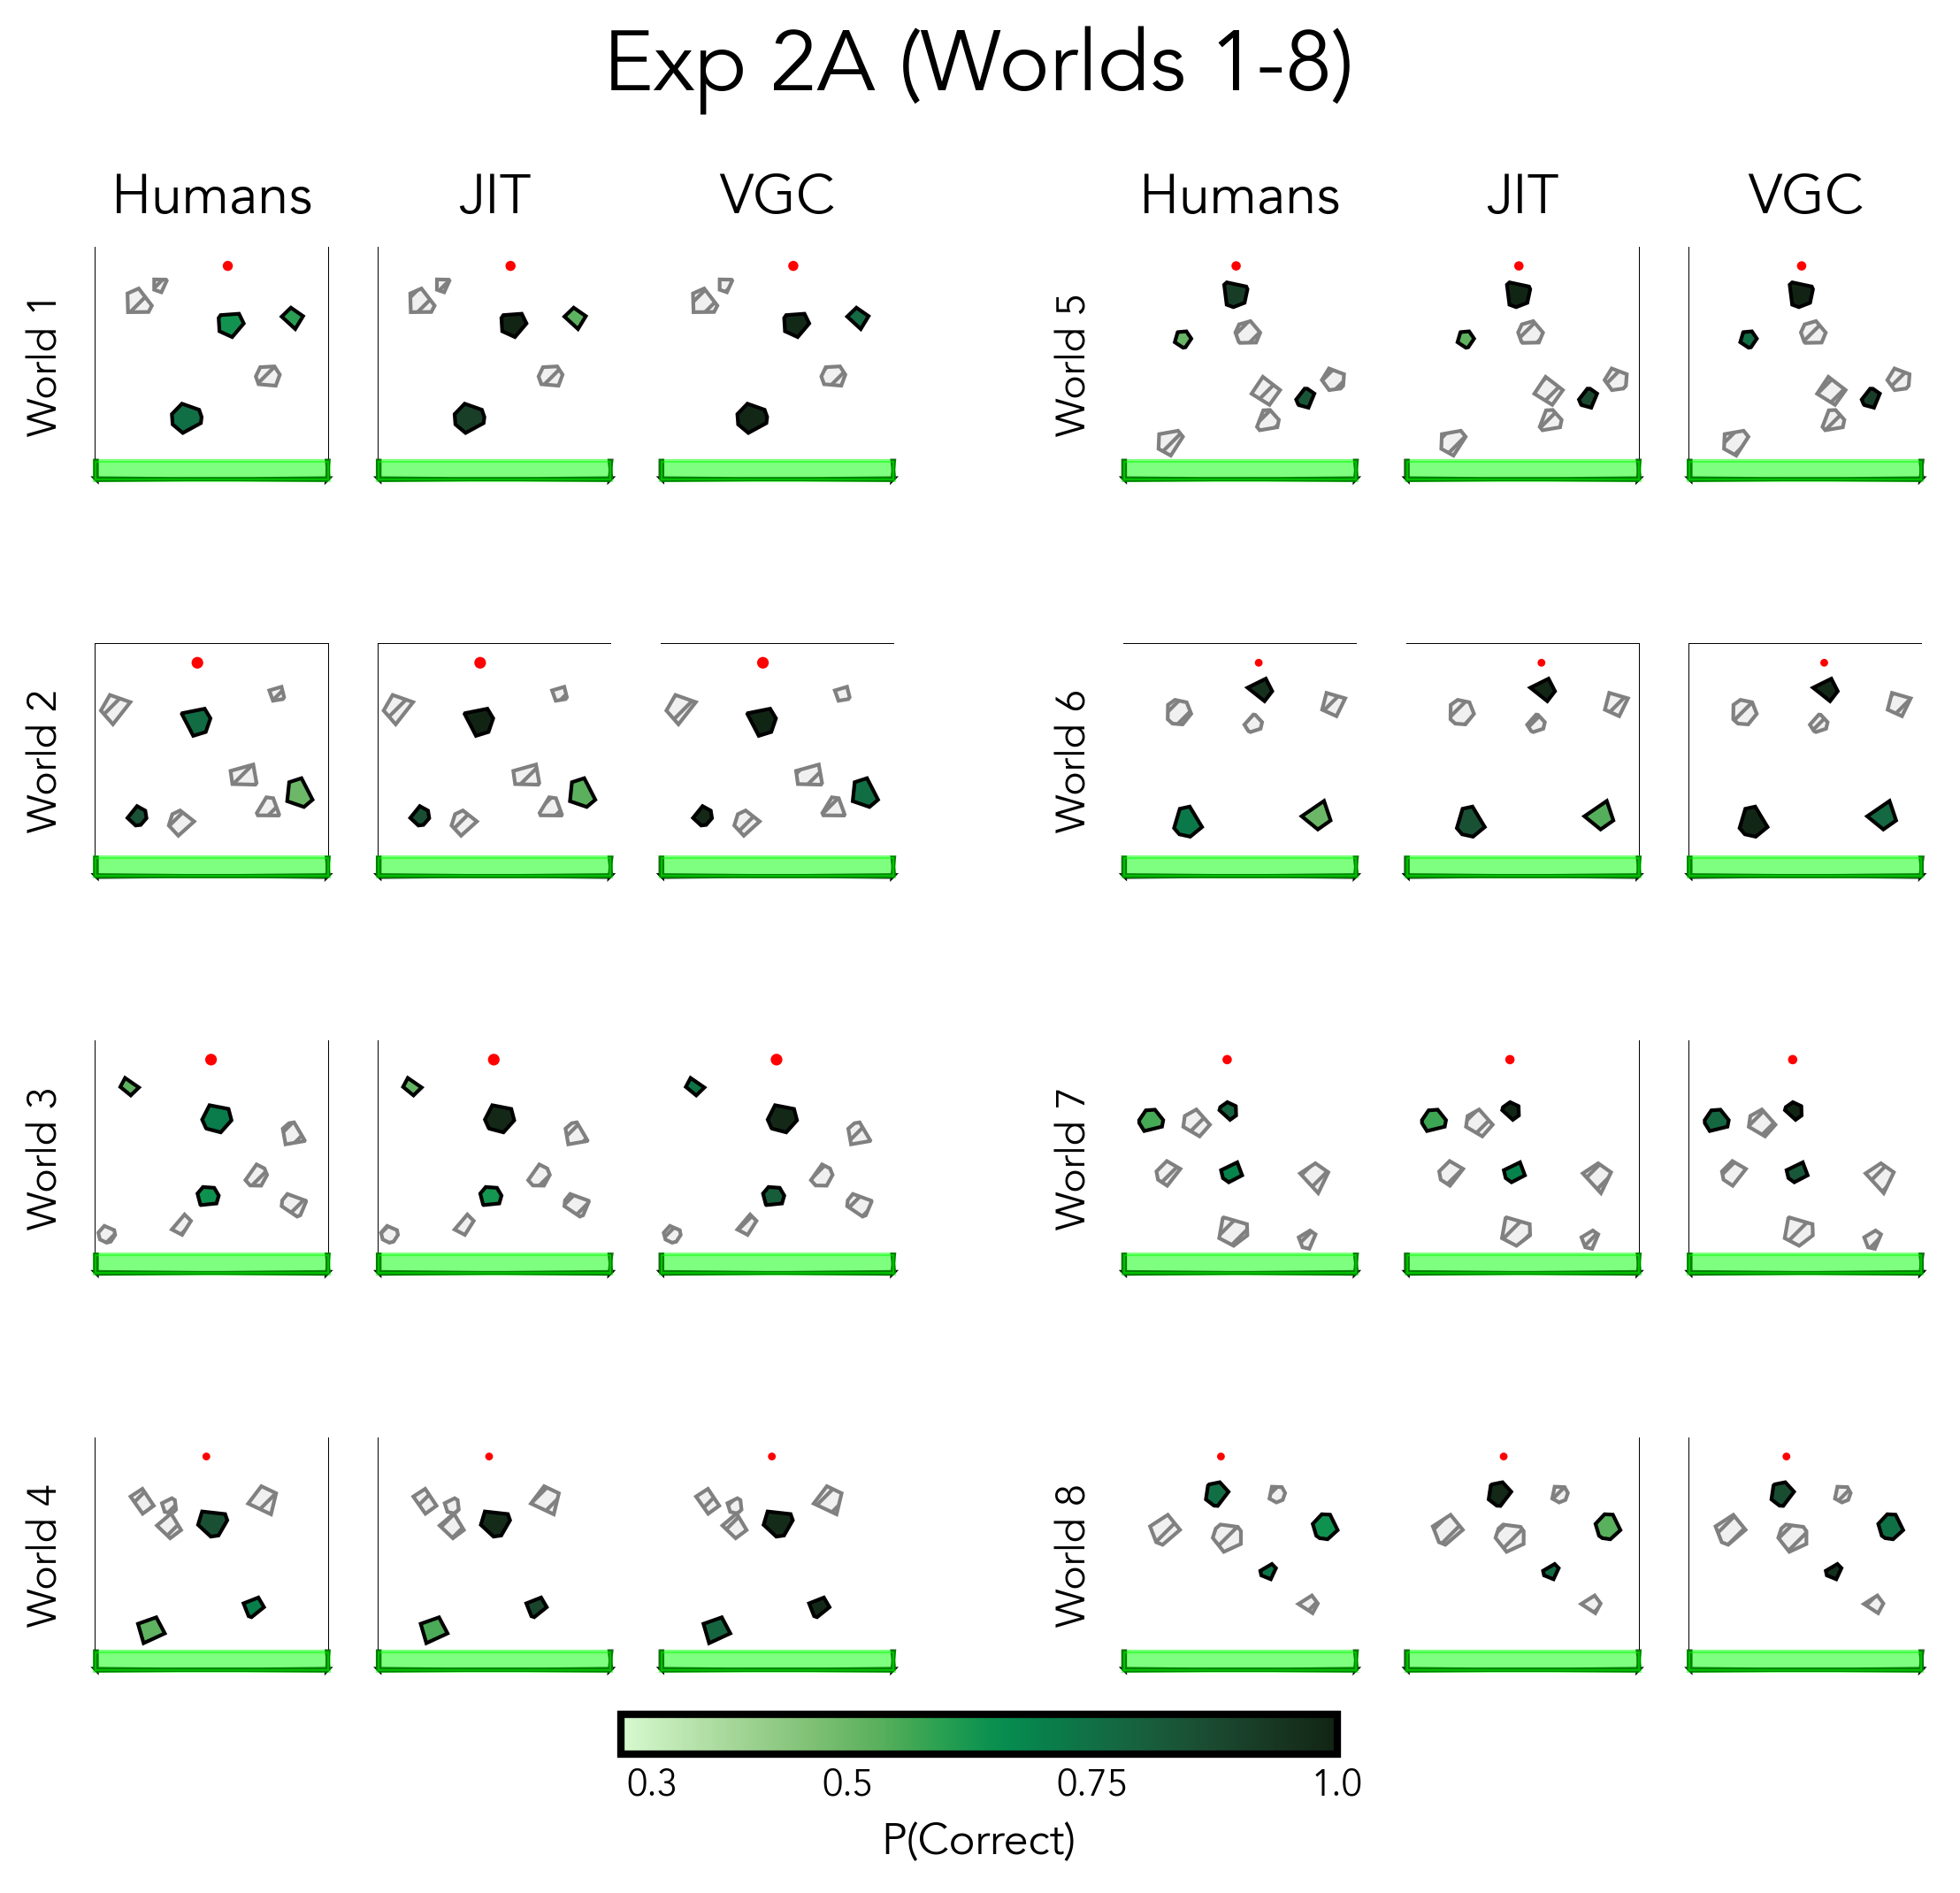

In [46]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(1.5 * 6, 2.1 * 4 - 1), dpi=300)
outer = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
left = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[0], wspace=0.1, hspace=0.1)
right = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[1], wspace=0.1, hspace=0.1)
for j, gs in enumerate([left, right]):
    for i, wname in enumerate(list(worlds)[j*4:(j+1)*4]):
        axes = []
        for k in range(3):
            axes.append(fig.add_subplot(gs[i, k]))
        world = worlds[wname]
        heatmap(world, joint_predictions_all[joint_predictions_all.world == wname], collisions_person[collisions_person.world == wname], axes=axes, ground_truth=False)
        axes[0].set_ylabel(f"World {j*4 + i+1}", fontsize=11)
        if i % 4 != 0:
            for ax in axes:
                ax.set_title("")
fig.suptitle("Exp 2A (Worlds 1-8)")
fig.subplots_adjust(top=0.90)
colorbar_ax = fig.add_axes([0.35, 0.1, 0.3, 0.02])
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), cax=colorbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('P(Correct)', fontsize=12)
cbar.ax.set_xticks([0.3, 0.5, 0.75, 1.0], ['0.3', '0.5', '0.75', '1.0'], fontsize=10)
fig.savefig("../../figures/plinko_heatmaps1.pdf", bbox_inches="tight")

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86729/2977094095.py:103: UserWarning: This figure includes Axes that 

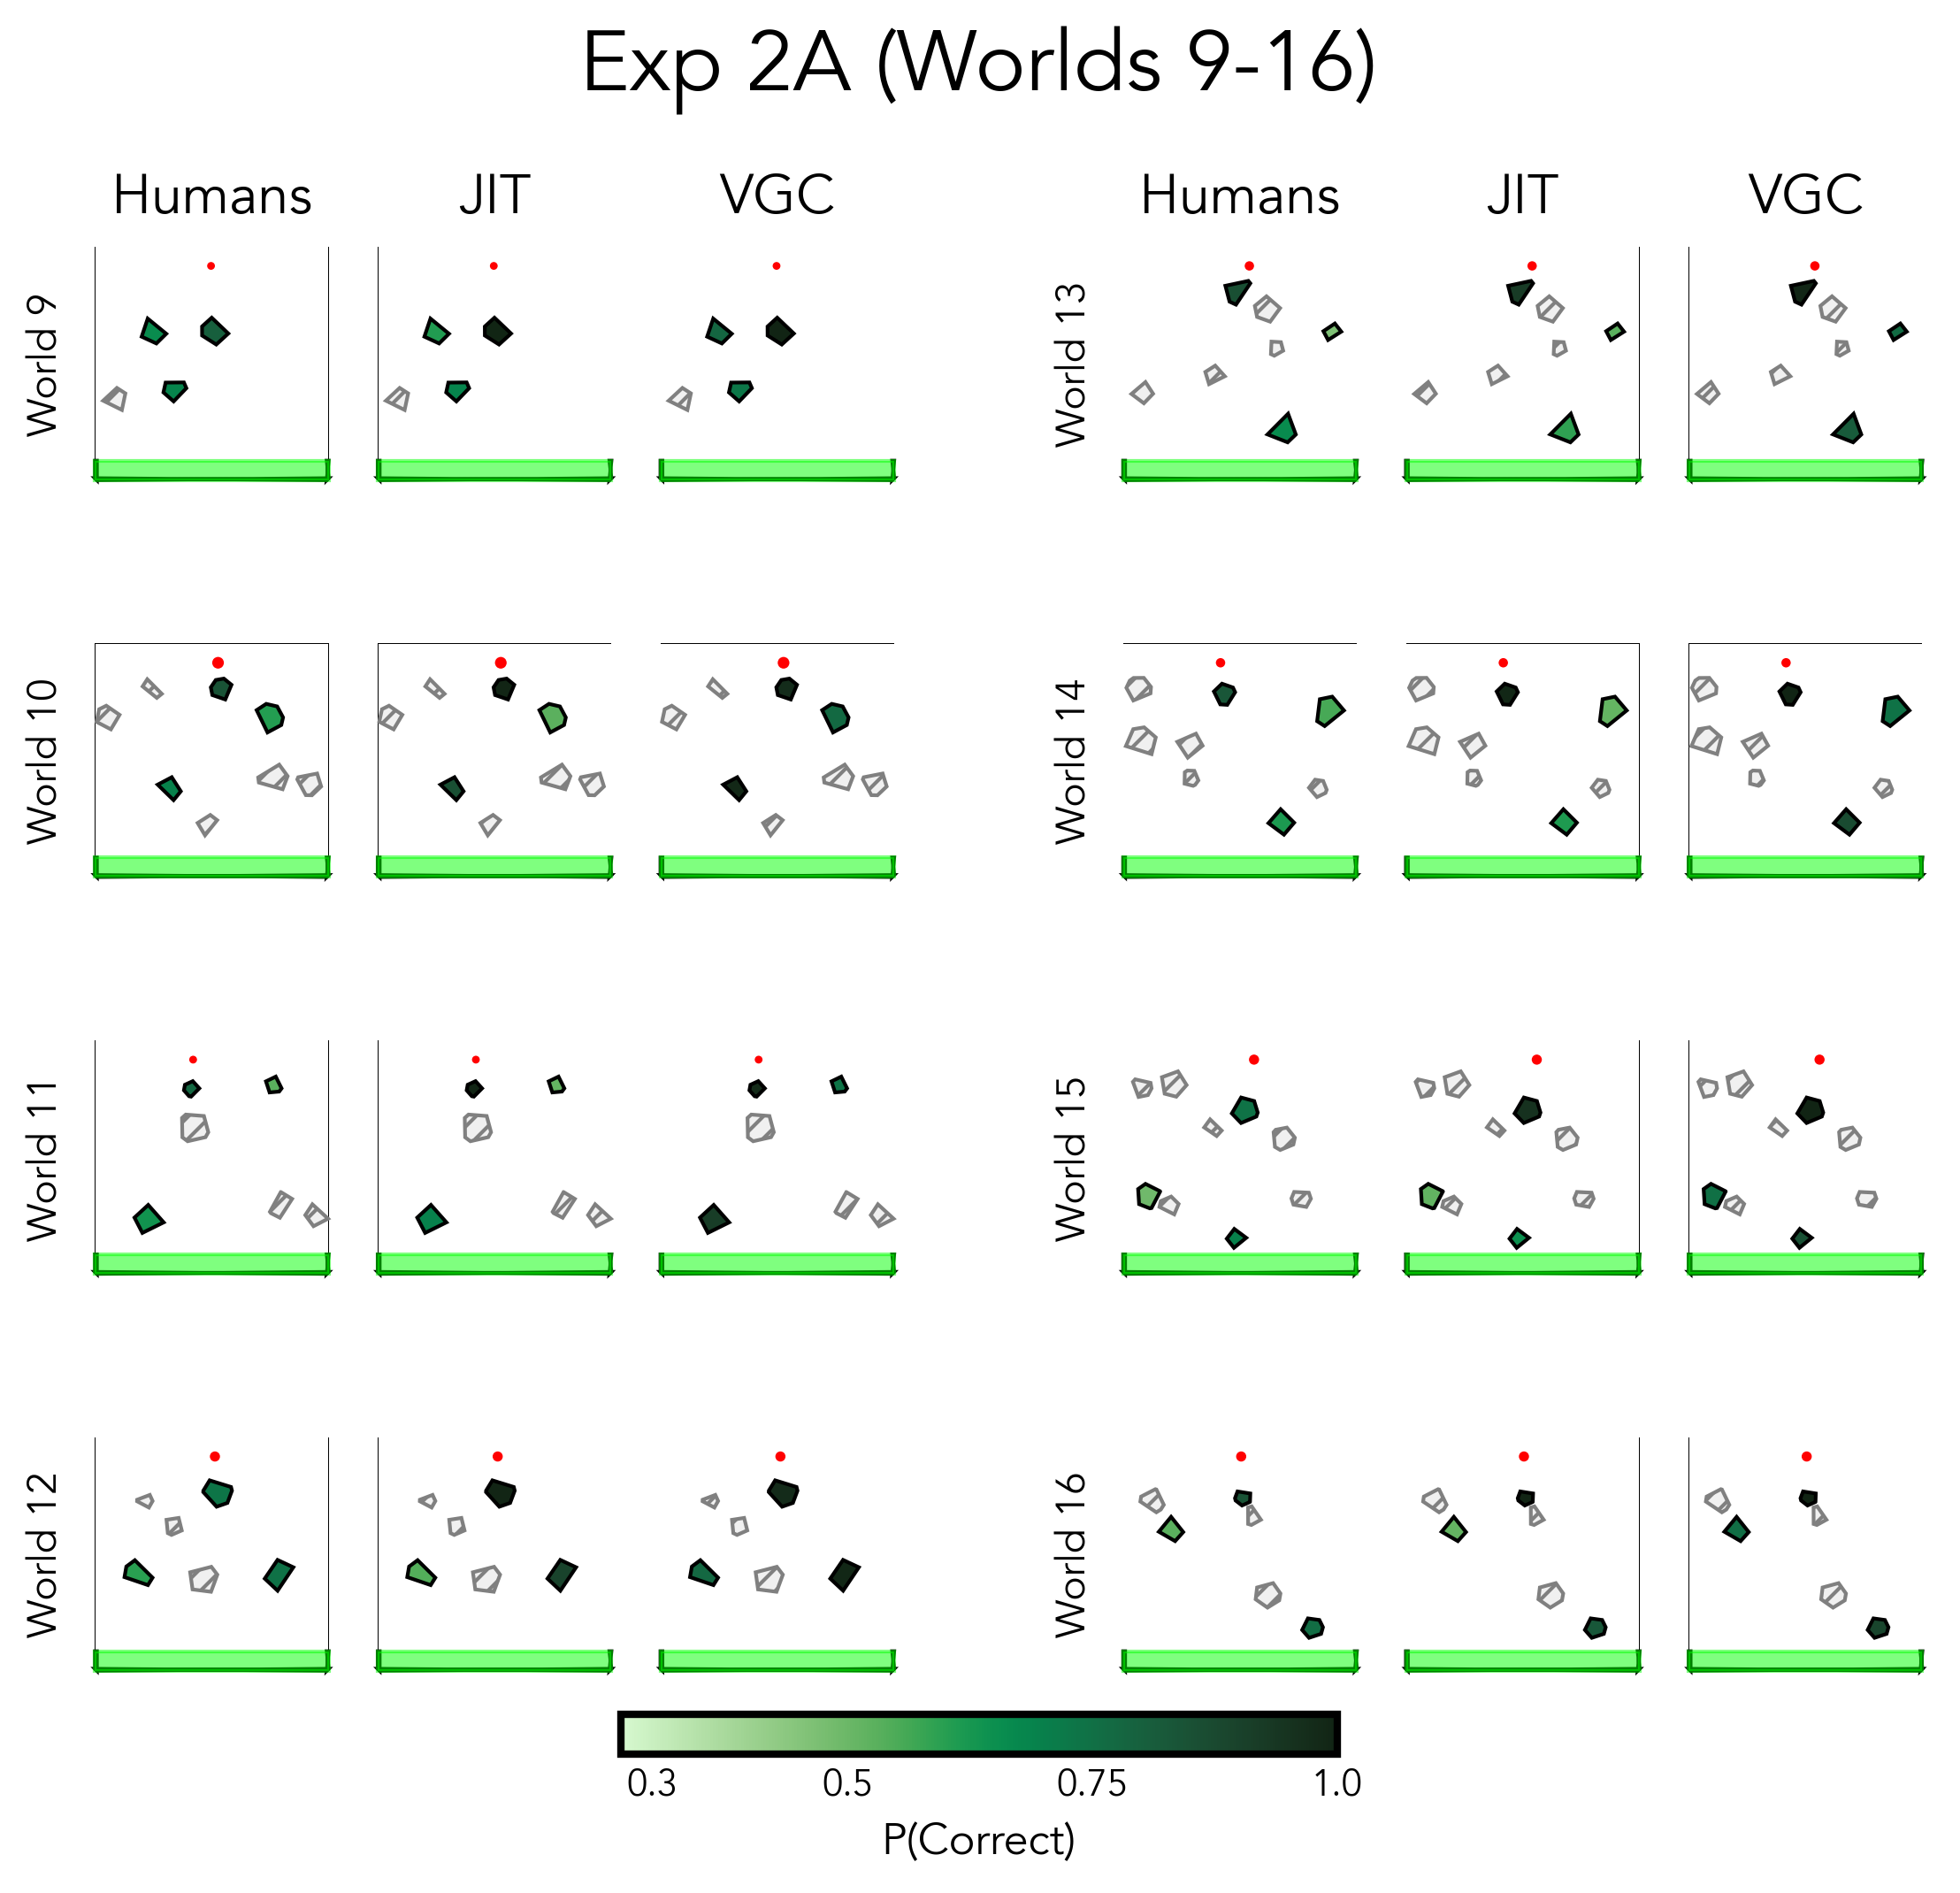

In [47]:
fig = plt.figure(figsize=(1.5 * 6, 2.1 * 4 - 1), dpi=300)
outer = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
left = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[0], wspace=0.1, hspace=0.1)
right = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[1], wspace=0.1, hspace=0.1)
for j, gs in enumerate([left, right]):
    for i, wname in enumerate(list(worlds)[(8 + j*4):(8 + (j+1)*4)]):
        axes = []
        for k in range(3):
            axes.append(fig.add_subplot(gs[i, k]))
        world = worlds[wname]
        heatmap(world, joint_predictions_all[joint_predictions_all.world == wname], collisions_person[collisions_person.world == wname], axes=axes, ground_truth=False)
        axes[0].set_ylabel(f"World {8 + j*4 + i+1}", fontsize=11)
        if i % 4 != 0:
            for ax in axes:
                ax.set_title("")
fig.suptitle("Exp 2A (Worlds 9-16)")
fig.subplots_adjust(top=0.90)
colorbar_ax = fig.add_axes([0.35, 0.1, 0.3, 0.02])
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), cax=colorbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('P(Correct)', fontsize=12)
cbar.ax.set_xticks([0.3, 0.5, 0.75, 1.0], ['0.3', '0.5', '0.75', '1.0'], fontsize=10)
fig.savefig("../../figures/plinko_heatmaps2.pdf", bbox_inches="tight")

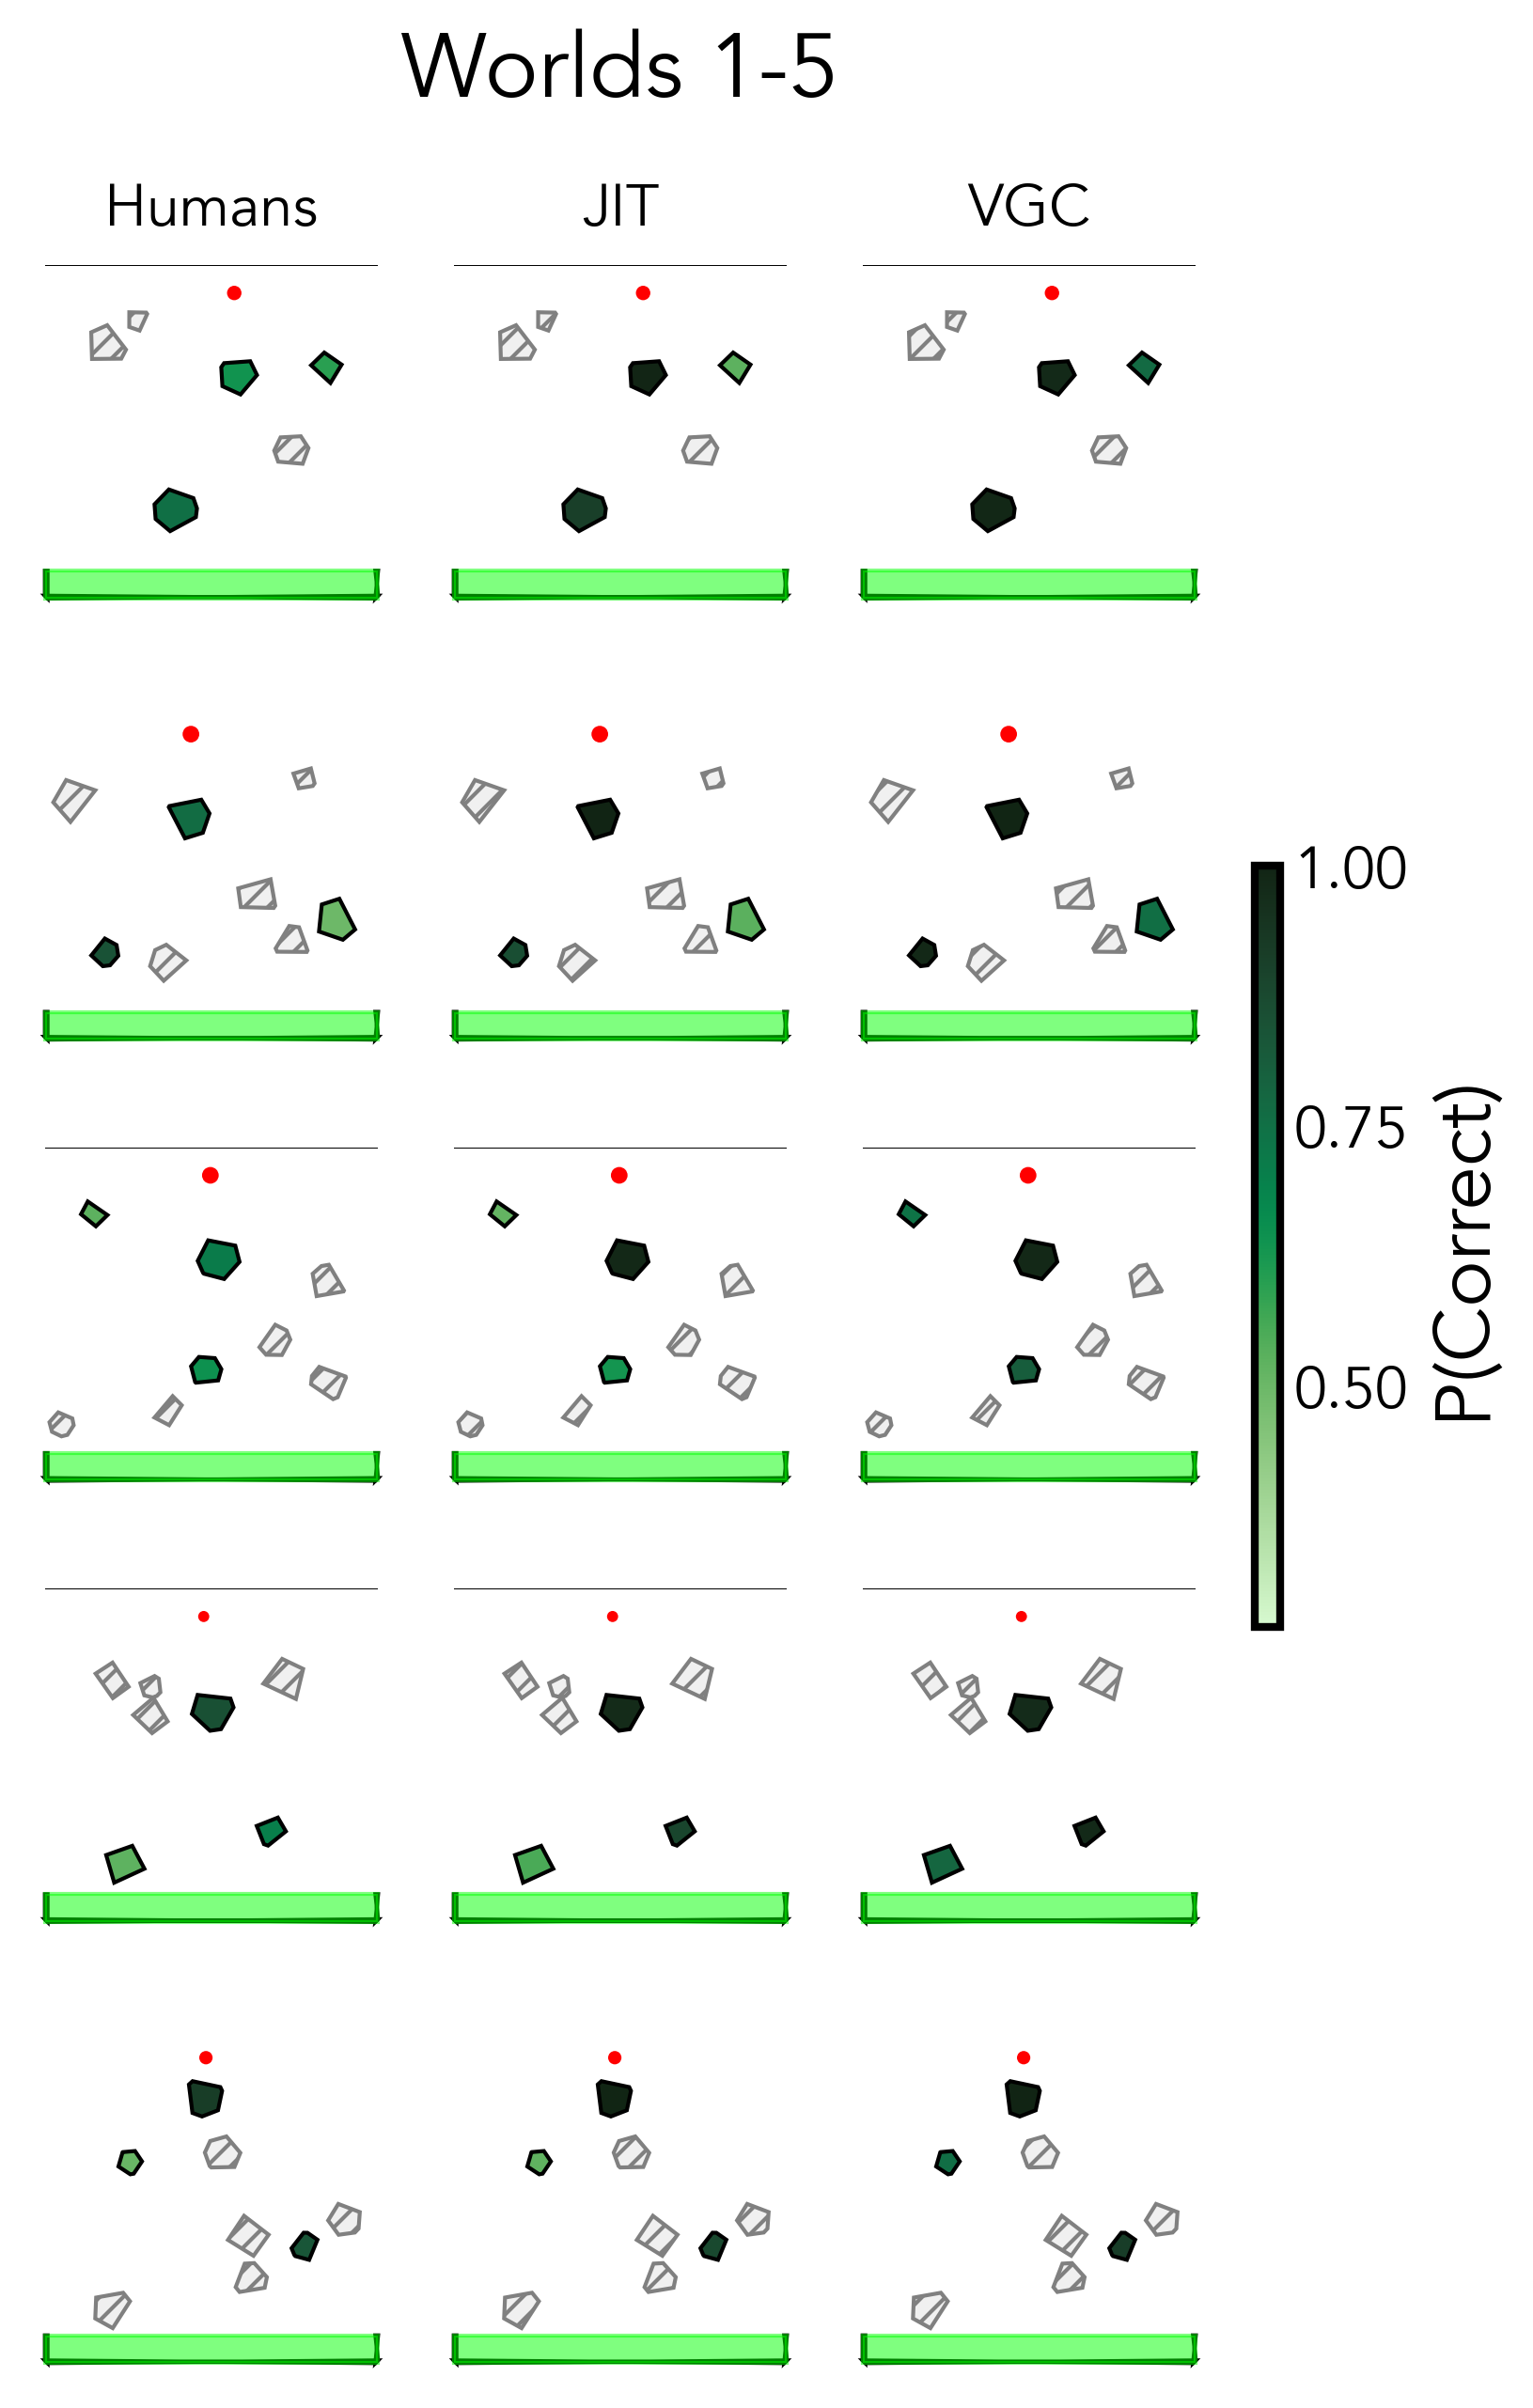

In [48]:
fig, axes = plt.subplots(5, 3, figsize=(1.5*3, 5 * 2 - 1), dpi=300)
for i, wname in enumerate(list(worlds)[:5]):
    world = worlds[wname]
    heatmap(world, joint_predictions_all[joint_predictions_all.world == wname], collisions_person[collisions_person.world == wname], axes=axes[i], ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")
fig.suptitle("Worlds 1-5")
fig.subplots_adjust(top=0.90)
plt.tight_layout()
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), cax=colorbar_ax, orientation='vertical', label='P(Correct)', ticks=[0.25, 0.5, 0.75, 1.0])

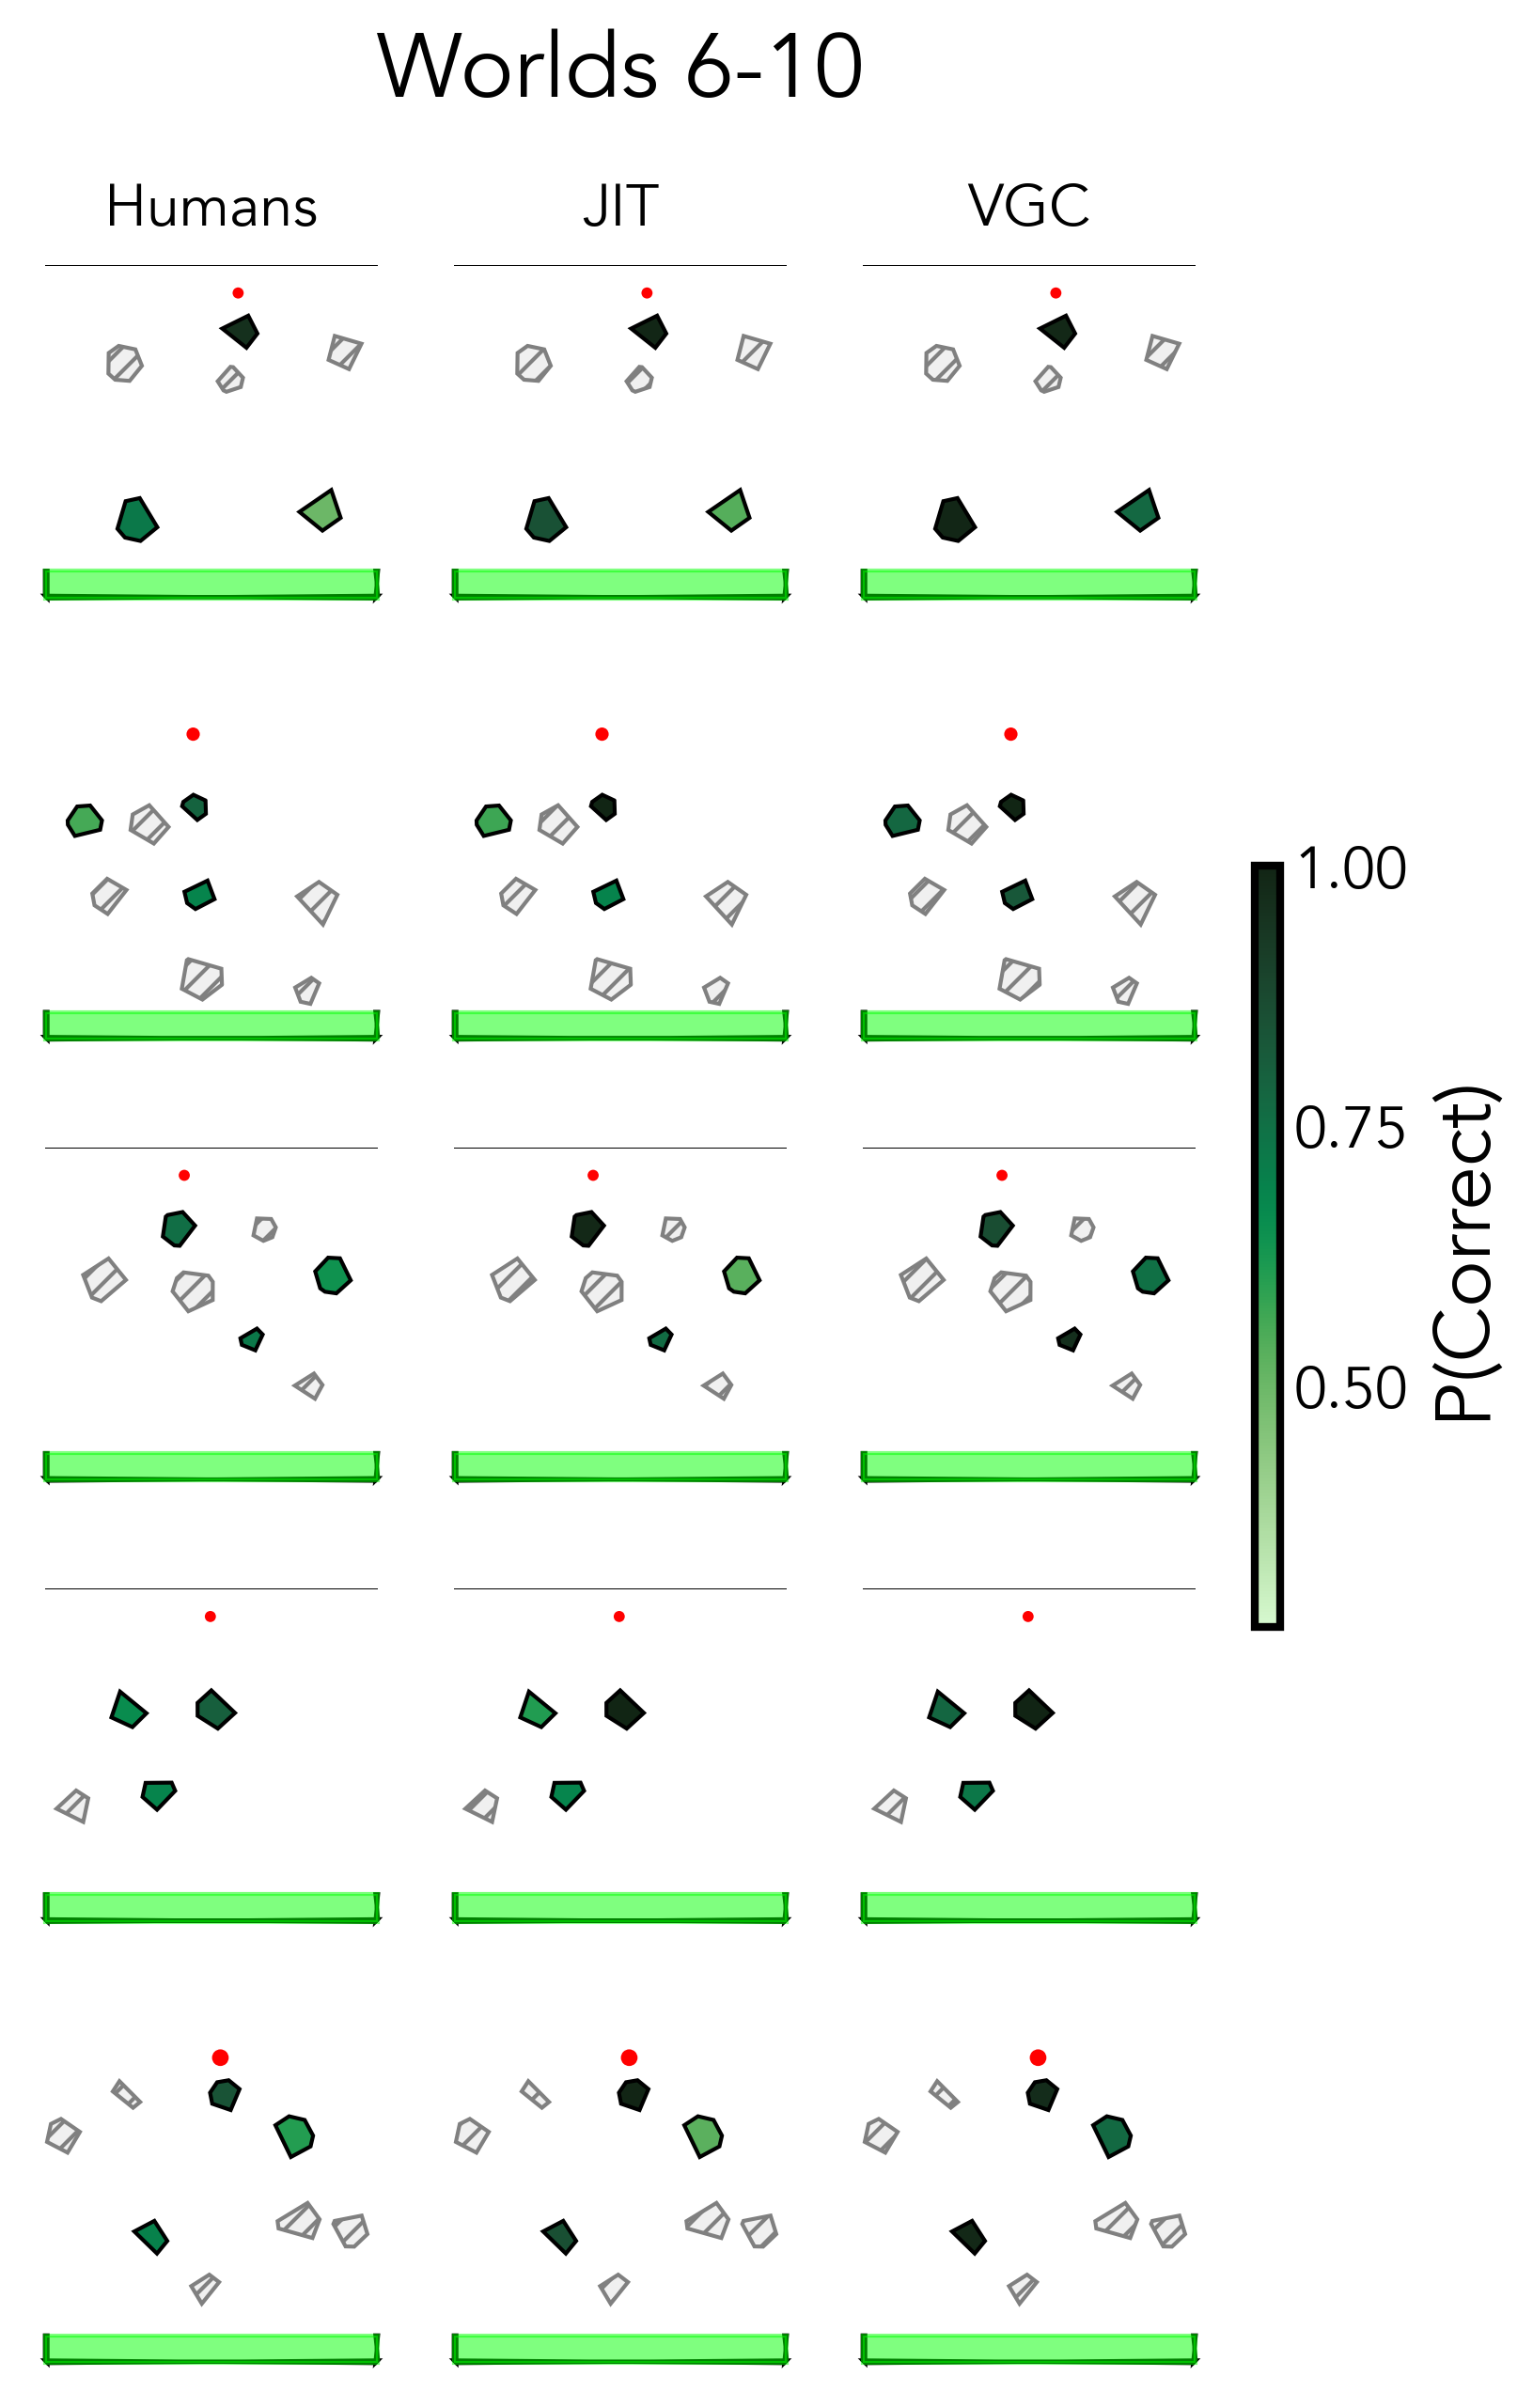

In [49]:
fig, axes = plt.subplots(5, 3, figsize=(1.5*3, 5 * 2 -1), dpi=300)
# for i, wname in enumerate(["lh_ll_unlink_plinko_0217", "hh_hl_unlink_plinko_0252"]):
for i, wname in enumerate(list(worlds)[5:10]):
    world = worlds[wname]
    heatmap(world, joint_predictions_all[joint_predictions_all.world == wname], collisions_person[collisions_person.world == wname], axes=axes[i], ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")
fig.suptitle("Worlds 6-10")
fig.subplots_adjust(top=0.90)
plt.tight_layout()
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), cax=colorbar_ax, orientation='vertical', label='P(Correct)', ticks=[0.25, 0.5, 0.75, 1.0])
fig.savefig("../../figures/plinko_heatmaps2.pdf", bbox_inches="tight")

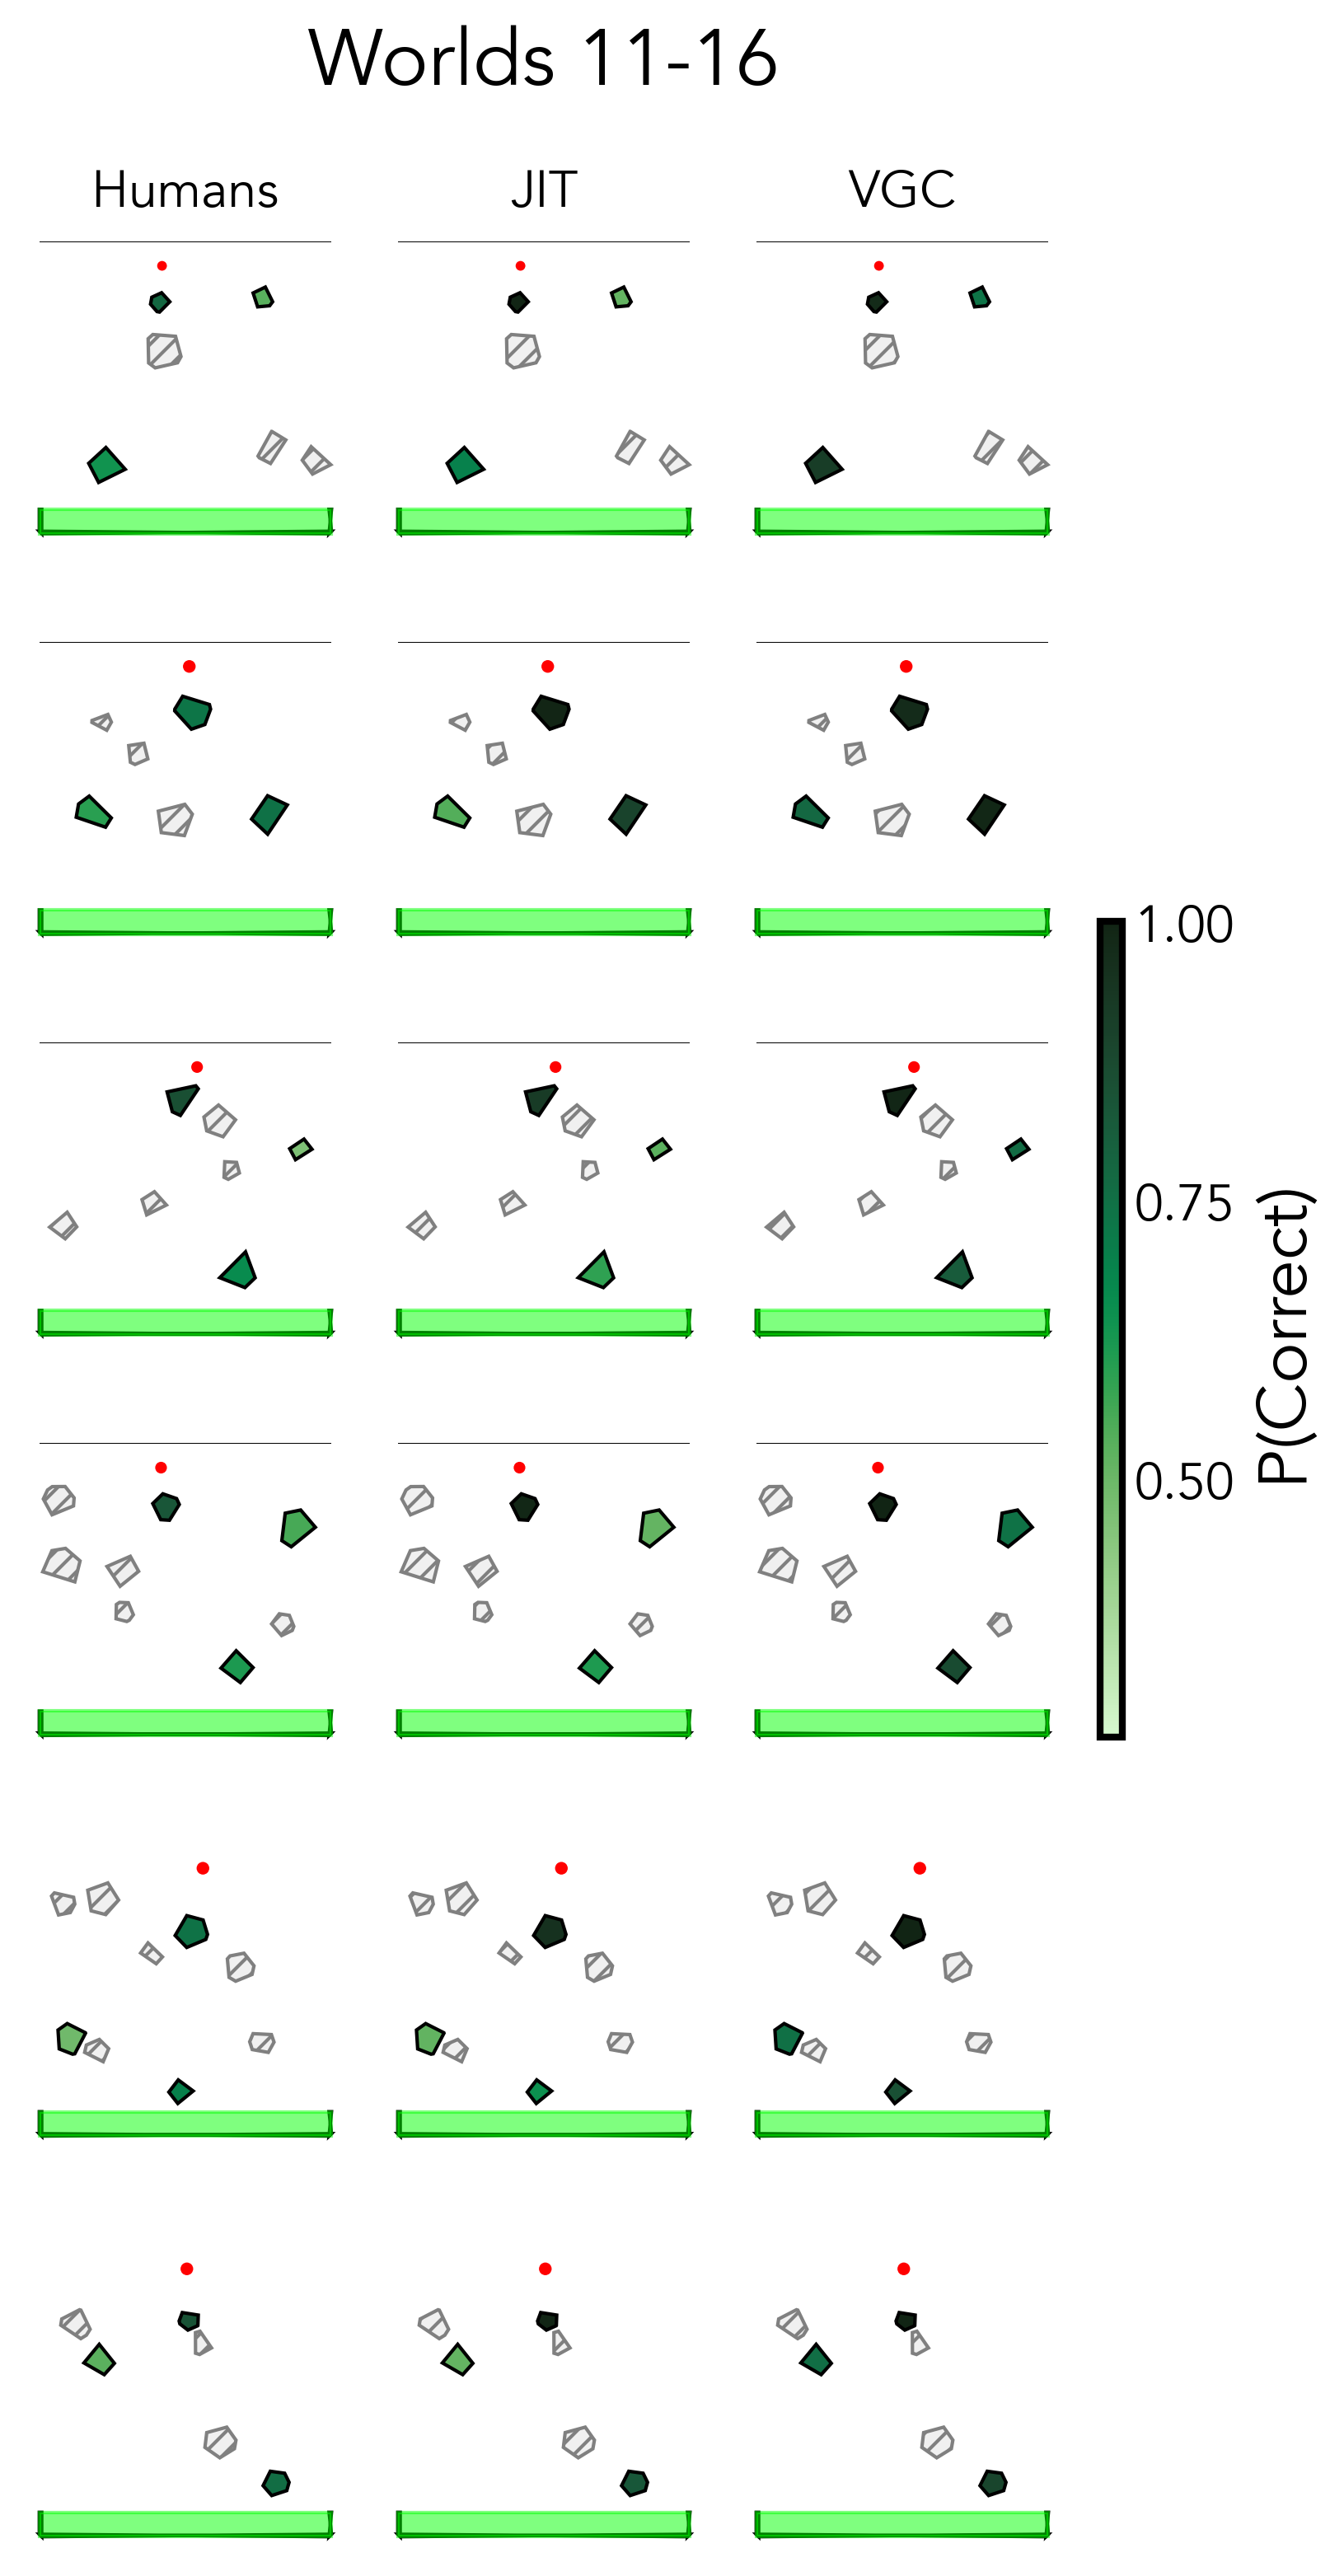

In [50]:
fig, axes = plt.subplots(6, 3, figsize=(1.5 * 3, 2 * 6 - 1), dpi=300)
# for i, wname in enumerate(["lh_ll_unlink_plinko_0217", "hh_hl_unlink_plinko_0252"]):
for i, wname in enumerate(list(worlds)[10:]):
    world = worlds[wname]
    heatmap(world, joint_predictions_all[joint_predictions_all.world == wname], collisions_person[collisions_person.world == wname], axes=axes[i], ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")
fig.suptitle("Worlds 11-16")
fig.subplots_adjust(top=0.90)
plt.tight_layout()
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), cax=colorbar_ax, orientation='vertical', label='P(Correct)', ticks=[0.25, 0.5, 0.75, 1.0])
fig.savefig("../../figures/plinko_heatmaps3.pdf", bbox_inches="tight")

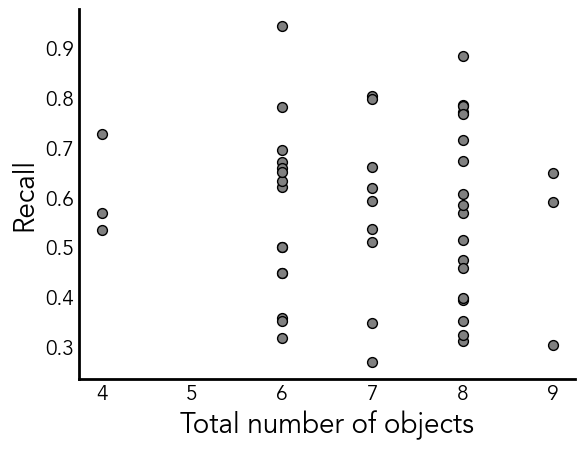

In [51]:
@lru_cache
def world_objects(world):
    with open(f"../../experiments/assets/exp1/targets/{world}/{world}.json") as f:
        jdict = json.load(f)

    return sum(1 if "bump" in o else 0 for o in jdict["world"]["objects"])

tmp = collisions_person.copy()
tmp["n_objects"] = tmp.world.map(world_objects)
# tmp["acc_confidence"] /= 100
plt.scatter(data=tmp, x="n_objects", y="correct", color="gray", s=50, ec="k", lw=1)
plt.xlabel("Total number of objects")
plt.ylabel("Recall")
# plt.legend([], [], title=f"$R^2$={tmp.n_objects.corr(tmp.acc_confidence)**2:.2f}", loc="lower left")
plt.savefig("../../figures/plinko_worldsize_control.pdf", bbox_inches="tight")

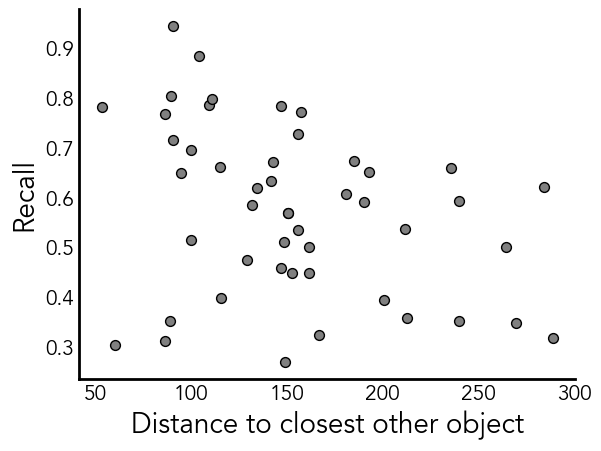

In [52]:
@lru_cache
def closest_object(world, obj_name):
    with open(f"../../experiments/assets/exp1/targets/{world}/{world}.json") as f:
        jdict = json.load(f)

    w = pgw.loadFromDict(jdict["world"])
    target_center = pgw.centroidForPoly(w.objects[obj_name].vertices)

    min_dist = float("inf")
    for oname, o in w.objects.items():
        if "bump" not in oname:
            continue
        if oname == obj_name:
            continue

        center = pgw.centroidForPoly(o.vertices)
        if np.sqrt((target_center[0] - center[0]) ** 2 + (target_center[1] - center[1]) ** 2) < min_dist:
            min_dist = np.sqrt((target_center[0] - center[0]) ** 2 + (target_center[1] - center[1]) ** 2)

    return min_dist

tmp = collisions_person.copy()
tmp["min_dist"] = tmp.apply(lambda row: closest_object(row.world, row.object), axis=1)
tmp["acc_confidence"] /= 100
plt.scatter(data=tmp, x="min_dist", y="correct", color="gray", s=50, ec="k", lw=1)
plt.xlabel("Distance to closest other object")
plt.ylabel("Recall")
# plt.legend([], [], title=f"$R^2$={tmp.min_dist.corr(tmp.acc_confidence)**2:.2f}", loc="lower left")
plt.savefig("../../figures/plinko_distance_control.pdf", bbox_inches="tight")

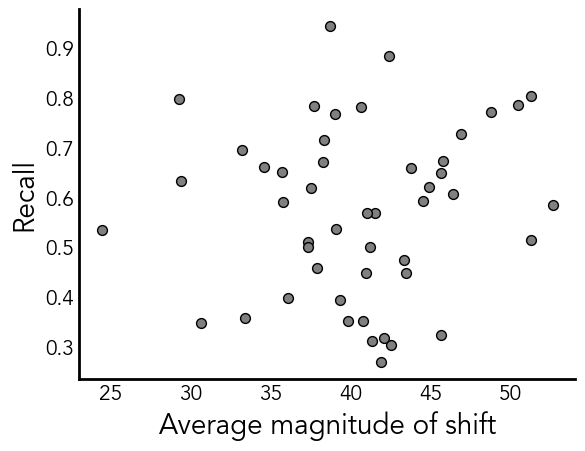

In [53]:
from glob import glob

@lru_cache
def shift_magnitude(world, obj_name, obj_cond: str):
    # with open(f"../../experiments/assets/exp1/targets/{world}/{world}.json") as f:
    #     jdict = json.load(f)

    # w = pgw.loadFromDict(jdict["world"])

    shift_files = glob(f"../../experiments/assets/exp1/targets/{world}/{obj_cond}*blue.json")
    shifts = 0

    for shift in shift_files:
        with open(shift) as f:
            data = json.load(f)
            # print(data)
            shifts += np.sqrt(data["shiftx"] ** 2 + data["shifty"] ** 2)

    return shifts / 2

tmp = collisions_person.copy()
tmp["shift"] = tmp.apply(lambda row: shift_magnitude(row.world, row.object, row.cond), axis=1)
# tmp["acc_confidence"] /= 100
plt.scatter(data=tmp, x="shift", y="correct", color="gray", s=50, ec="k", lw=1)
plt.xlabel("Average magnitude of shift")
plt.ylabel("Recall")
# plt.legend([], [], title=f"$R^2$={tmp.min_dist.corr(tmp.acc_confidence)**2:.2f}", loc="lower left")
plt.savefig("../../figures/plinko_shift_control.pdf", bbox_inches="tight")

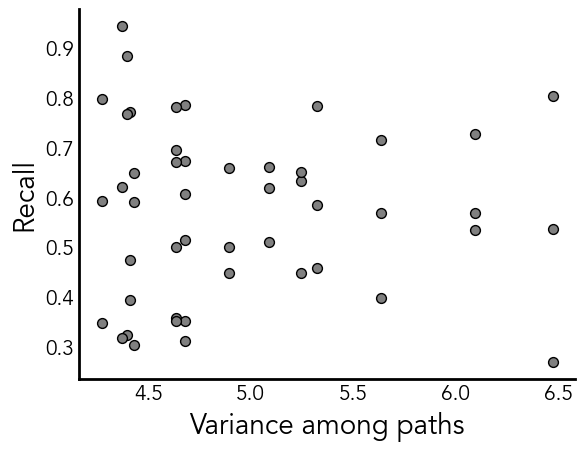

In [54]:
sys.path.append("../../stimuli")
from create_plinko import PlinkoCreator

@lru_cache
def midpath_variance(world, obj_name):
    with open(f"../../experiments/assets/exp1/targets/{world}/{world}.json") as f:
        jdict = json.load(f)

    midpoints = []
    outcomes = jdict["outcome"]["noisePaths"]
    for p in outcomes:
        splittime = p["sensors"][0][1]

        sim_stepsize = 0.1
        splitidx_sim = int((splittime / sim_stepsize) + 0.0000001)
        # toppath = {"path": {"FOCUS": p["path"]["FOCUS"][:splitidx_sim]}}
        # bottompath = {"path": {"FOCUS": p["path"]["FOCUS"][splitidx_sim:]}}
        midpoints.append(p["path"]["FOCUS"][splitidx_sim][0])
    # print(outcomes[0].keys())
    # print(outcomes[0]["sensors"])
    # print(midpoints)
    # print(len(midpoints))
    return np.std(midpoints)

tmp = collisions_person.copy()
tmp["midpath_std"] = tmp.apply(lambda row: midpath_variance(row.world, row.object), axis=1)
plt.scatter(data=tmp, x="midpath_std", y="correct", color="gray", s=50, ec="k", lw=1)
plt.xlabel("Variance among paths")
plt.ylabel("Recall")
plt.savefig("../../figures/plinko_midpath_control.pdf", bbox_inches="tight")

In [55]:
combined_predictors = joint_predictions_all.copy()
combined_predictors["n_objects"] = combined_predictors.world.map(world_objects)
combined_predictors["min_dist"] = combined_predictors.apply(lambda row: closest_object(row.world, row.object), axis=1)
combined_predictors["shift"] = combined_predictors.apply(lambda row: shift_magnitude(row.world, row.object, row.cond), axis=1)
combined_predictors["midpath_std"] = combined_predictors.apply(lambda row: midpath_variance(row.world, row.object), axis=1)
combined_predictors

,collision_likelihood,world,object,acc_confidence,acc_confidence_z,acc_confidence_z_ci,confidence,confidence_ci,confidence_z,confidence_z_ci,...,N,model_p,relevance_del_norm,relevance_norm,vgc,alpha,n_objects,min_dist,shift,midpath_std
0,91.083333,hh_hl_unlink_plinko_0105,topbump_1,78.912281,0.610825,0.139467,35.929825,2.276592,0.739124,0.133100,...,57,0.974836,0.977955,0.971064,0.996313,20.033333,8,157.135178,48.749229,4.411928
1,33.346154,hh_hl_unlink_plinko_0105,bottombump_0,52.863636,-0.253781,0.075967,17.263636,1.509971,-0.344425,0.070557,...,110,0.206490,0.812528,0.706102,0.724837,20.033333,8,128.977530,43.323822,4.411928
2,6.583333,hh_hl_unlink_plinko_0105,topbump_4,47.921569,-0.472255,0.105011,15.450980,2.263836,-0.731529,0.122399,...,51,0.004301,0.577717,0.608166,0.472406,20.033333,8,200.482417,39.306296,4.411928
3,99.461538,hh_hl_unlink_plinko_0202,topbump_0,67.779661,0.351952,0.131254,31.406780,2.195995,0.455839,0.110278,...,59,0.985444,0.977069,0.994335,0.952733,20.033333,6,99.958366,33.199727,4.634670
4,35.666667,hh_hl_unlink_plinko_0202,bottombump_2,55.933962,-0.207774,0.091725,23.311321,1.647801,-0.109536,0.079333,...,106,0.372175,0.988435,0.942209,0.825035,20.033333,6,264.193081,41.217627,4.634670
5,10.846154,hh_hl_unlink_plinko_0202,topbump_2,47.728814,-0.426422,0.096474,12.203390,1.841114,-0.528468,0.116622,...,59,0.004017,0.999998,0.680886,0.459412,20.033333,6,212.547258,33.396263,4.634670
6,93.500000,hh_hl_unlink_plinko_0240,topbump_1,76.327273,0.483420,0.134294,34.981818,2.307431,0.769570,0.112514,...,55,0.990746,0.999950,0.999881,0.999611,20.033333,4,156.015432,46.900632,6.093958
7,74.076923,hh_hl_unlink_plinko_0240,bottombump_1,56.293578,-0.142759,0.091433,22.403670,1.607995,-0.061915,0.077042,...,109,0.347465,0.793982,0.805578,0.433680,20.033333,4,150.669926,41.535190,6.093958
8,14.083333,hh_hl_unlink_plinko_0240,topbump_0,56.400000,-0.227483,0.104698,17.000000,1.865839,-0.437365,0.108548,...,60,0.193711,0.851107,0.710428,0.545449,20.033333,4,156.015432,24.466304,6.093958
9,98.083333,hh_hl_unlink_plinko_0246,topbump_3,79.941176,0.837168,0.142291,37.549020,2.227865,0.905979,0.147478,...,51,0.840826,0.999903,0.981210,0.980661,20.033333,7,89.829556,51.257080,6.473212


In [56]:
print(combined_predictors.n_objects.corr(combined_predictors.correct))
print(combined_predictors["shift"].corr(combined_predictors.correct))
print(combined_predictors.midpath_std.corr(combined_predictors.correct))
print(combined_predictors.min_dist.corr(combined_predictors.correct))
print(partial_correlation(combined_predictors.min_dist, combined_predictors.correct, combined_predictors.model_p))
print(semipartial_correlation(combined_predictors.min_dist, combined_predictors.correct, combined_predictors.model_p))

-0.0625279002293305
0.09265981142537968
-0.007446821612347313
-0.3306741834525897
-0.2482088030439117
-0.12434168691669603


In [57]:
def zscore(series):
    return (series - series.mean()) / series.std()

regression_data = pd.merge(data[["world", "object", "correct", "pid"]], combined_predictors[["world", "object", "model_p", "vgc", "relevance_norm", "shift", "n_objects", "min_dist", "midpath_std"]], on=["world", "object"])
regression_data["shift"] = zscore(regression_data["shift"])
regression_data["n_objects"] = zscore(regression_data["n_objects"])
regression_data["min_dist"] = zscore(regression_data["min_dist"])
regression_data["midpath_std"] = zscore(regression_data["midpath_std"])


In [58]:
%%R -i regression_data

library(lme4)
overall_model = glmer("correct ~ 1 + (1 | pid) + model_p + vgc + relevance_norm + n_objects + shift + min_dist + midpath_std", data=regression_data, family=binomial)
aic <- AIC(overall_model)
print(aic)
model_nojit = glmer("correct ~ 1 + (1 | pid) + vgc + relevance_norm + n_objects + shift + min_dist + midpath_std", data=regression_data, family=binomial)
model_novgc = glmer("correct ~ 1 + (1 | pid) + model_p + relevance_norm + n_objects + shift + min_dist + midpath_std", data=regression_data, family=binomial)
model_nometacognitive = glmer("correct ~ 1 + (1 | pid) + model_p + vgc + n_objects + shift + min_dist + midpath_std", data=regression_data, family=binomial)
model_noshift = glmer("correct ~ 1 + (1 | pid) + model_p + vgc + relevance_norm + n_objects + min_dist + midpath_std", data=regression_data, family=binomial)
model_noobj = glmer("correct ~ 1 + (1 | pid) + model_p + vgc + relevance_norm + shift + min_dist + midpath_std", data=regression_data, family=binomial)
model_nodist = glmer("correct ~ 1 + (1 | pid) + model_p + vgc + relevance_norm + n_objects + shift + midpath_std", data=regression_data, family=binomial)
model_nostd = glmer("correct ~ 1 + (1 | pid) + model_p + vgc + relevance_norm + n_objects + shift + min_dist", data=regression_data, family=binomial)

print("no jit, no vgc, no metacognitive, no shift, no obj, no dist, no std")
print(c(AIC(model_nojit) - aic, AIC(model_novgc) - aic, AIC(model_nometacognitive) - aic, AIC(model_noshift) - aic, AIC(model_noobj) - aic, AIC(model_nodist) - aic, AIC(model_nostd) - aic))

[1] 4483.736
[1] "no jit, no vgc, no metacognitive, no shift, no obj, no dist, no std"
[1] 21.3379195 -0.7147515 -1.1543893 -1.6768510 -1.9802896  3.4585841 -1.1736612


In addition: Warning messages:
1: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model failed to converge with max|grad| = 0.0114329 (tol = 0.002, component 1)
2: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model failed to converge with max|grad| = 0.0049308 (tol = 0.002, component 1)


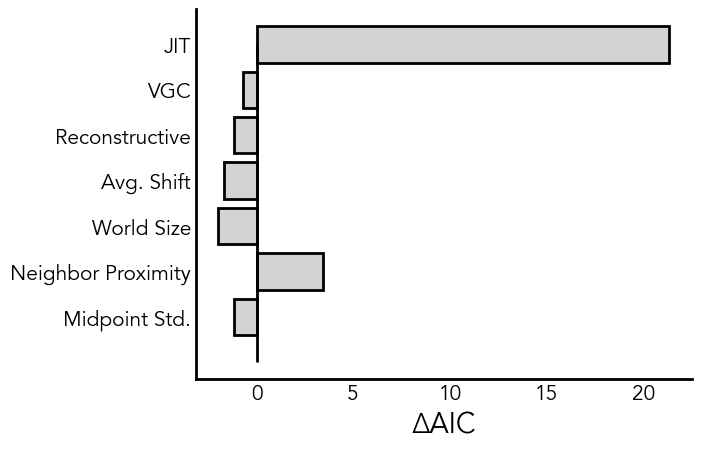

In [59]:
aics = [21.3379195, -0.7147515, -1.1543893, -1.6768510, -1.9802896,  3.4585841, -1.1736612]
labels = ["JIT", "VGC", "Reconstructive", "Avg. Shift", "World Size", "Neighbor Proximity", "Midpoint Std."]
ticks = list(range(-1, -len(labels)-1, -1))

for i in range(len(aics)):
    plt.barh(ticks[i], aics[i], color="lightgray", edgecolor="k", lw=2)

plt.vlines(0, -1, -len(labels)-1, color="k", lw=2)
plt.yticks(ticks, labels)
plt.xlabel("ΔAIC")
plt.savefig("../../figures/plinko_model_comparison.pdf", bbox_inches="tight", dpi=300)

In [60]:
def get_avg_pcorrect(wname, cond, var, alpha):
    transforms = process_model.lookup_transform(wname, cond)

    corrects = 0
    for t in transforms:
        p_correct = process_model.forced_choice(var, t, alpha=alpha)
        corrects += p_correct
    return corrects / len(transforms)

kappa = 75
alpha = 0.0296
_joint_predictions = joint_predictions.copy()
_joint_predictions["post_var"] = _joint_predictions.model_p.apply(process_model.object_pos_dist, kappa=kappa).tolist()
_joint_predictions["model_p_choice"] = _joint_predictions.apply(lambda row: get_avg_pcorrect(row.world, row.cond, row.post_var, alpha), axis=1)


RMSE: 0.22265378257370672


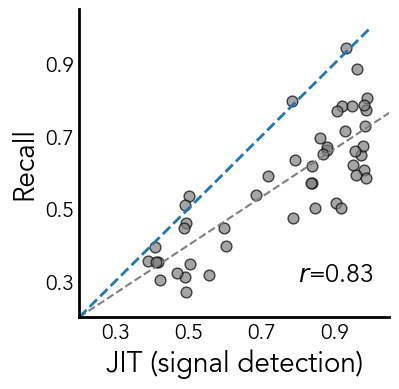

In [61]:
import random

tmp = _joint_predictions.copy()
# tmp["correct"] = (tmp.correct - tmp.correct.min()) / (tmp.correct.max() - tmp.correct.min())
# tmp["correct"] = tmp.correct * 0.5 + 0.5
# tmp["model_logit"] = tmp.model_p.apply(logit)
# tmp["acc_confidence"] /= 100
fig, ax = plt.subplots(figsize=(4, 4))
tmp["model_p_choice"] = (2 * tmp["model_p_choice"] - 1) * 0.667 + 0.333
dv = "model_p_choice"
plt.scatter(
    x=dv,
    y="correct",
    alpha=0.7,
    lw=1,
    ec="k",
    color="tab:gray",
    s=60,
    data=tmp
)

b, a = np.polyfit(tmp[dv], tmp.correct, 1)
# xlims = ax.get_xlim()
lims = (0.2, 1.05)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.axline((lims[0], a + b * lims[0]), (lims[1], a + b * lims[1]), ls="--", c="gray")
plt.plot([lims[0], 1.0], [lims[0], 1.0], ls="--", c="tab:blue", lw=2)

plt.xlabel("JIT (signal detection)")
plt.ylabel("Recall")
# plt.title("Recall (Exp 2A)")
# plt.legend([], title=f"$r$={tmp.groupby(['world', 'cond'])[[dv, 'correct']].mean().corr().iloc[0, 1]:.2f}",
        # loc = "lower center")
plt.text(0.80, 0.3, f"$r$={tmp.groupby(['world', 'cond'])[[dv, 'correct']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
print("RMSE:", np.sqrt(((tmp["correct"] - tmp[dv]) ** 2).mean()))
plt.yticks(np.arange(0.3, 1.0, 0.2))
plt.xticks(np.arange(0.3, 1.0, 0.2))
plt.savefig("../../figures/jit_signal_detection.pdf", dpi=300, bbox_inches="tight")

(-1.9, 1.9)


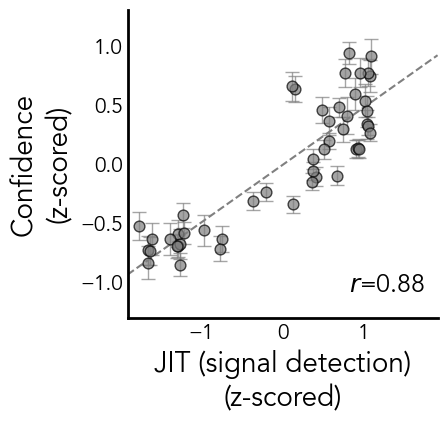

In [62]:
tmp = _joint_predictions.copy()
tmp["model_p_z"] = (tmp.model_p_choice - tmp.model_p_choice.mean()) / tmp.model_p_choice.std()
fig, ax = plt.subplots(figsize=(4, 4))
plt.errorbar(
    x="model_p_z",
    y="confidence_z",
    yerr="confidence_z_ci",
    fmt="o",
    alpha=0.7,
    lw=1,
    markeredgecolor="k",
    color="tab:gray",
    ms=np.sqrt(60),
    elinewidth=1,
    capsize=5,
    capthick=1,
    data=tmp
)
b, a = np.polyfit(tmp.model_p_z, tmp.confidence_z, 1)

ax.set_xlim((-1.9, 1.9))
ax.set_ylim((-1.3, 1.3))
xlims = ax.get_xlim()
print(xlims)
ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
plt.xlabel("JIT (signal detection)\n(z-scored)")
plt.ylabel("Confidence\n(z-scored)")
# plt.title("Confidence (Exp 2A)")
plt.legend([], title=f"$r$={tmp.groupby(['world', 'cond'])[['model_p_z', 'confidence_z']].mean().corr().iloc[0, 1]:.2f}",
        loc="lower right", frameon=False, title_fontproperties={"weight": "bold", "size": 18})
# plt.text(0.75, 0.037, f"$r$={tmp.groupby(['world', 'cond'])[['model_p', 'confidence']].mean().corr().iloc[0, 1]:.2f}", fontsize=18, fontweight="bold")
        # bbox_to_anchor=(.4, .8))
# fig.tight_layout()
# fig.subplots_adjust(bottom=0.15)
# fig.tight_layout(pad=50)
fig.savefig("../../figures/jit_signal_detection_confidence.pdf", dpi=300, bbox_inches="tight")
# plt.show()

In [64]:
losses = []
for kappa in np.arange(15, 100, 15):
    for alpha in np.linspace(0.01, 0.5, 51):
        _joint_predictions["post_var"] = _joint_predictions.model_p.apply(process_model.object_pos_dist, kappa=float(kappa)).tolist()
        _joint_predictions["model_p_choice"] = _joint_predictions.apply(lambda row: get_avg_pcorrect(row.world, row.cond, row.post_var, alpha), axis=1)
        tmp = _joint_predictions.copy()
        losses.append((kappa, alpha, np.sqrt(((tmp["correct"] - tmp["model_p_choice"]) ** 2).mean()), tmp["correct"].corr(tmp["model_p_choice"])))
losses = pd.DataFrame(losses, columns=["kappa", "alpha", "rmse", "r"])
print(losses.sort_values("r", ascending=False).head(10))

     kappa   alpha      rmse         r
206     75  0.0296  0.266804  0.825786
258     90  0.0394  0.280383  0.825421
154     60  0.0198  0.243073  0.824093
257     90  0.0296  0.244242  0.823942
51      30  0.0100  0.242904  0.823490
103     45  0.0198  0.278045  0.822708
155     60  0.0296  0.291953  0.820611
207     75  0.0394  0.299878  0.819643
259     90  0.0492  0.305340  0.819308
205     75  0.0198  0.214011  0.817680
